# Linear versus nonlinear contrastive encoders

We compare linear encoders against MLP nonlinear encoders on pure-noise data, linear paired-signal data, and cubic paired-signal data. The goal is to see when nonlinear capacity helps learn a relationship between two random views, and when it mainly increases the risk of fitting noise.


## 1. Imports

The path setup lets this notebook work when Jupyter starts in the repository root.


In [45]:
from __future__ import annotations

from pathlib import Path
import sys

import numpy as np
import pandas as pd
import torch

GLOBAL_SEED = 123
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

P_DIM = 128
Q_DIM = 128

cwd = Path.cwd()
if (cwd / "contrastive_encoders").exists():
    module_root = cwd
else:
    raise RuntimeError("Could not find the contrastive_encoders package folder.")

if str(module_root) not in sys.path:
    sys.path.insert(0, str(module_root))

PLOT_DIR = module_root / "reports" / "report-plots"
PLOT_DIR.mkdir(parents=True, exist_ok=True)

print("DEVICE:", DEVICE)
print("module_root:", module_root)
print("plot output:", PLOT_DIR)


DEVICE: cpu
module_root: /Users/b4her/Desktop/git-repos/Remote/utssrp-cca-contrastive-encoders
plot output: /Users/b4her/Desktop/git-repos/Remote/utssrp-cca-contrastive-encoders/reports/report-plots


In [46]:
import importlib

import contrastive_encoders
from contrastive_encoders import (
    architectures,
    data,
    experiments,
    losses,
    metrics,
    plotting,
    regularization,
    training,
)

for module in [
    architectures,
    data,
    losses,
    metrics,
    regularization,
    training,
    experiments,
    plotting,
]:
    importlib.reload(module)

importlib.reload(contrastive_encoders)

from contrastive_encoders import (
    TrainConfig,
    friendly_results_table,
    generate_deterministic_relation_dataset,
    make_experiment_datasets,
    make_first_experiment_configs,
    make_model_spec_table,
    paper_contrastive_loss,
    plot_alpha_sweep_curve,
    plot_branch_ratio_history,
    plot_deterministic_snr_sweep,
    plot_metric_by_config,
    plot_signal_noise_sweep,
    plot_signal_recovery_by_config,
    plot_similarity_heatmap,
    plot_top5_retrieval_by_setting,
    plot_train_test_separation_by_setting,
    run_alpha_sweep,
    run_deterministic_relation_experiment,
    run_first_experiment,
    run_signal_noise_sweep,
    train_one_model_with_artifacts,
)


## 2. Mathematical objective

For embeddings `z_x = f_X(X)` and `z_y = f_Y(Y)`, define

```text
s_ij = <z_x_i, z_y_j>
```

The paper objective maximizes

```text
L = sum_i s_ii
    - sum_i log sum_j exp(s_ij)
    - sum_i log sum_j exp(s_ji)
```

The training code minimizes `-L / N` using `paper_contrastive_loss(...)`.

Important: this is **not** the standard cross-entropy InfoNCE replacement. By default it uses raw inner products, no loss-side normalization, and temperature `1.0`. The encoder architecture now has internal branch normalization so `alpha` controls the nonlinear correction, but the paper loss itself is unchanged.


## 3. Model comparison grid

The pure linear baseline is now a normalized linear encoder:

```text
g(u) = Normalize(G u)
```

The residual nonlinear models normalize both branches so `alpha` controls the nonlinear correction:

```text
g(u) = Normalize(G u) + alpha * Normalize(A1 sigma(A2 u + b))
```

The normalization layers use `BatchNorm1d(..., affine=False)`. The `affine=False` part is important because it prevents a learned scale parameter from secretly undoing `alpha`.

This also keeps the pure linear embedding scale controlled before the raw-dot-product loss sees it. So `alpha=0` means no nonlinear correction, while larger `alpha` lets the normalized MLP correction contribute more strongly.


In [47]:
configs = make_first_experiment_configs(epochs=300)
model_table = make_model_spec_table(configs, p=P_DIM, q=Q_DIM)
display(model_table)


,Model,Plain meaning,Encoder formula,Linear layer sizes,Nonlinear layer sizes,Embedding dim,Hidden dim,Alpha,Alpha meaning,Normalization,Nonlinear role,L1 penalty,L2 penalty,Trainable parameters
0,Linear encoder (alpha=0),Only a normalized linear map for X and Y,g(u) = Normalize(G u),X G: 128->4; Y G: 128->4,none,4,none,0.00,alpha is not used for the pure linear baseline,encoder output uses BatchNorm1d affine=False,"alpha=0, so no nonlinear correction is added",none,none,1024
1,MLP nonlinear (alpha=0.01),Linear map plus a one-hidden-layer MLP correction,g(u) = Normalize(G u) + alpha * Normalize(A1 s...,X G: 128->4; Y G: 128->4,"X A2: 128->16, X A1: 16->4; Y A2: 128->16, Y A...",4,16,0.01,alpha multiplies the normalized nonlinear corr...,residual branches use BatchNorm1d affine=False,alpha=0.01 scales the normalized MLP correction,none,none,5280
2,MLP nonlinear (alpha=0.10),Linear map plus a one-hidden-layer MLP correction,g(u) = Normalize(G u) + alpha * Normalize(A1 s...,X G: 128->4; Y G: 128->4,"X A2: 128->16, X A1: 16->4; Y A2: 128->16, Y A...",4,16,0.10,alpha multiplies the normalized nonlinear corr...,residual branches use BatchNorm1d affine=False,alpha=0.1 scales the normalized MLP correction,none,none,5280
3,MLP nonlinear (alpha=1.00),Linear map plus a one-hidden-layer MLP correction,g(u) = Normalize(G u) + alpha * Normalize(A1 s...,X G: 128->4; Y G: 128->4,"X A2: 128->16, X A1: 16->4; Y A2: 128->16, Y A...",4,16,1.00,alpha multiplies the normalized nonlinear corr...,residual branches use BatchNorm1d affine=False,alpha=1 scales the normalized MLP correction,none,none,5280
4,L1-regularized nonlinear (alpha=0.10),Linear map plus a one-hidden-layer MLP correction,g(u) = Normalize(G u) + alpha * Normalize(A1 s...,X G: 128->4; Y G: 128->4,"X A2: 128->16, X A1: 16->4; Y A2: 128->16, Y A...",4,16,0.10,alpha multiplies the normalized nonlinear corr...,residual branches use BatchNorm1d affine=False,alpha=0.1 scales the normalized MLP correction,A2=0.0001,none,5280
5,L2-regularized nonlinear (alpha=0.10),Linear map plus a one-hidden-layer MLP correction,g(u) = Normalize(G u) + alpha * Normalize(A1 s...,X G: 128->4; Y G: 128->4,"X A2: 128->16, X A1: 16->4; Y A2: 128->16, Y A...",4,16,0.10,alpha multiplies the normalized nonlinear corr...,residual branches use BatchNorm1d affine=False,alpha=0.1 scales the normalized MLP correction,none,A1/A2=0.0001,5280


## 4. Run pure-noise, linear-signal, and cubic-signal experiments

The experiment creates three datasets:

- `Noise only`: X and Y are independent noise, so there is no real paired signal.
- `Linear signal`: X has latent `Z_x`, Y has latent `Z_y`, and the relationship is `Z_y = Z_x`.
- `Cubic signal`: X has latent `Z_x`, Y has latent `Z_y`, and the relationship is `Z_y = standardized(Z_x ** 3)`.

This is closer to the caption/image analogy: the two views are different random datasets, but their hidden variables are related when a signal is present. Every model uses the same paper contrastive loss, so differences should come from model capacity and regularization.


In [48]:
results = run_first_experiment(
    configs=configs,
    seed=GLOBAL_SEED,
    device=DEVICE,
    n_train=160,
    n_test=800,
    p=P_DIM,
    q=Q_DIM,
    signal_strength=2.0,
    noise_std=1.0,
)

results


,setting,config,architecture,embedding_dim,hidden_dim,nonlinear_scale,normalize_linear_part,l1_linear,l1_nonlinear,l2_linear,...,x_probe_r2_z_x,x_probe_r2_z_y,y_probe_r2_z_y,x_linear_branch_norm,x_nonlinear_branch_norm,x_nonlinear_to_linear_ratio,y_linear_branch_norm,y_nonlinear_branch_norm,y_nonlinear_to_linear_ratio,mean_nonlinear_to_linear_ratio
0,Noise only,Linear encoder (alpha=0),linear,4,0,0.00,True,0.0,0.0000,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Linear signal,Linear encoder (alpha=0),linear,4,0,0.00,True,0.0,0.0000,0.0,...,0.149317,0.149317,0.153143,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Cubic signal,Linear encoder (alpha=0),linear,4,0,0.00,True,0.0,0.0000,0.0,...,0.094494,0.049064,0.155226,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Noise only,MLP nonlinear (alpha=0.01),residual,4,16,0.01,True,0.0,0.0000,0.0,...,NaN,NaN,NaN,1.866164,0.018704,0.010023,1.781436,0.019416,0.010899,0.010461
4,Linear signal,MLP nonlinear (alpha=0.01),residual,4,16,0.01,True,0.0,0.0000,0.0,...,0.033547,0.033547,0.220868,1.895128,0.021211,0.011193,1.822931,0.019283,0.010578,0.010885
5,Cubic signal,MLP nonlinear (alpha=0.01),residual,4,16,0.01,True,0.0,0.0000,0.0,...,0.130910,0.101099,0.080782,1.844159,0.019802,0.010738,1.945187,0.019941,0.010251,0.010495
6,Noise only,MLP nonlinear (alpha=0.10),residual,4,16,0.10,True,0.0,0.0000,0.0,...,NaN,NaN,NaN,1.739613,0.196741,0.113095,1.769547,0.212591,0.120138,0.116617
7,Linear signal,MLP nonlinear (alpha=0.10),residual,4,16,0.10,True,0.0,0.0000,0.0,...,0.407462,0.407462,-0.106702,1.769418,0.220562,0.124652,1.701594,0.203286,0.119468,0.122060
8,Cubic signal,MLP nonlinear (alpha=0.10),residual,4,16,0.10,True,0.0,0.0000,0.0,...,0.230277,0.110724,0.214140,1.773773,0.198220,0.111750,1.877576,0.215258,0.114647,0.113199
9,Noise only,MLP nonlinear (alpha=1.00),residual,4,16,1.00,True,0.0,0.0000,0.0,...,NaN,NaN,NaN,1.743976,1.595543,0.914888,1.809877,1.764657,0.975015,0.944951


## 5. Focused comparison table

These are the main metrics in friendlier language:

- **True-pair separation**: true X/Y pairs score higher than mismatched pairs. Higher is better.
- **Shuffled-pair check**: the same score after breaking the X/Y pairing. This should stay near zero.
- **Exact-pair accuracy**: how often the closest Y is the true paired Y. Higher is better.
- **Top-5 retrieval accuracy**: how often the true paired Y is among the 5 closest Y candidates. Higher is better.
- **X embedding vs Z_x**: correlation between the X embedding and the true X latent.
- **X embedding vs Z_y**: correlation between the X embedding and the paired Y latent. In the cubic setting, this means `Z_y = standardized(Z_x ** 3)`.
- **Y embedding vs Z_y**: correlation between the Y embedding and the true Y latent.
- **Ridge-probe R^2**: percent of held-out latent variation explained by a simple ridge regression from the learned embedding.
- **Mean nonlinear/linear ratio**: diagnostic check that the measured nonlinear branch size follows `alpha`.


In [49]:
summary_columns = [
    "setting",
    "config",
    "architecture",
    "parameter_count",
    "parameter_count_per_train_sample",
    "train_pair_separation",
    "test_pair_separation",
    "shuffled_pair_separation",
    "test_pair_match_accuracy",
    "test_top5_pair_match_accuracy",
    "test_best_view_correlation",
    "x_signal_recovery",
    "x_related_signal_recovery",
    "y_signal_recovery",
    "x_probe_r2_z_x",
    "x_probe_r2_z_y",
    "y_probe_r2_z_y",
    "mean_nonlinear_to_linear_ratio",
]

summary_table = friendly_results_table(results[summary_columns].round(4))
display(summary_table)


,Dataset,Model,Architecture,Trainable parameters,Parameters per training pair,Train true-pair separation,Test true-pair separation,Shuffled-pair check,Test exact-pair accuracy,Test top-5 retrieval accuracy,Test X/Y embedding correlation,X signal recovery,X recovery of paired Y latent,Y signal recovery,X probe R^2 for Z_x,X probe R^2 for Z_y,Y probe R^2 for Z_y,Mean nonlinear/linear ratio
0,Noise only,Linear encoder (alpha=0),linear,1024,6.4,0.6401,-0.0011,-0.0215,0.0000,0.0088,0.0418,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Linear signal,Linear encoder (alpha=0),linear,1024,6.4,0.6764,0.0454,0.0199,0.0012,0.0075,0.0744,0.2483,0.2483,0.3047,0.1493,0.1493,0.1531,NaN
2,Cubic signal,Linear encoder (alpha=0),linear,1024,6.4,0.6732,0.0246,0.0278,0.0012,0.0038,0.1661,0.3045,0.2579,0.4850,0.0945,0.0491,0.1552,NaN
3,Noise only,MLP nonlinear (alpha=0.01),residual,5280,33.0,0.6488,0.0011,-0.0023,0.0012,0.0088,0.0381,NaN,NaN,NaN,NaN,NaN,NaN,0.0105
4,Linear signal,MLP nonlinear (alpha=0.01),residual,5280,33.0,0.6462,0.0760,0.0147,0.0000,0.0050,0.1062,0.3279,0.3279,0.4735,0.0335,0.0335,0.2209,0.0109
5,Cubic signal,MLP nonlinear (alpha=0.01),residual,5280,33.0,0.6582,0.0407,0.0174,0.0038,0.0062,0.1284,0.2919,0.2532,0.4946,0.1309,0.1011,0.0808,0.0105
6,Noise only,MLP nonlinear (alpha=0.10),residual,5280,33.0,0.6712,0.0155,-0.0032,0.0012,0.0050,0.0415,NaN,NaN,NaN,NaN,NaN,NaN,0.1166
7,Linear signal,MLP nonlinear (alpha=0.10),residual,5280,33.0,0.6836,0.0578,0.0076,0.0025,0.0062,0.1150,0.5970,0.5970,0.2692,0.4075,0.4075,-0.1067,0.1221
8,Cubic signal,MLP nonlinear (alpha=0.10),residual,5280,33.0,0.7013,0.0282,0.0020,0.0012,0.0100,0.1331,0.4851,0.3637,0.3760,0.2303,0.1107,0.2141,0.1132
9,Noise only,MLP nonlinear (alpha=1.00),residual,5280,33.0,0.9417,0.0013,-0.0136,0.0012,0.0038,0.0637,NaN,NaN,NaN,NaN,NaN,NaN,0.9450


## 6. Main plots

These plots separate the questions:

- Does the model memorize training pairs without generalizing?
- Does true-pair separation survive on held-out pairs?
- Is the true paired Y inside the top 5 retrieved candidates?
- Does the embedding recover `Z_x`, the transformed paired latent `Z_y`, or both?
- How much held-out latent variation is explained by a ridge probe from the embedding?
- Does the measured branch contribution follow `alpha`?

Each plot is also saved as a PNG in `reports/report-plots/` with a readable file name.


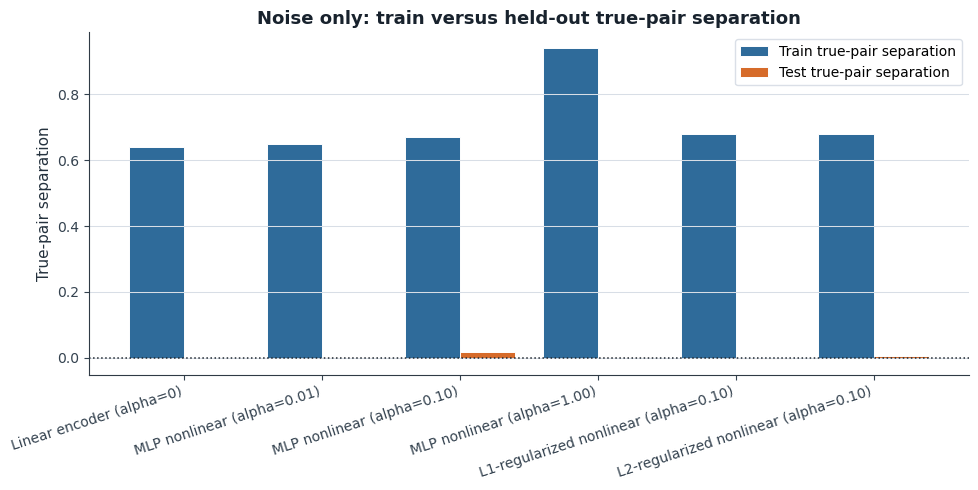

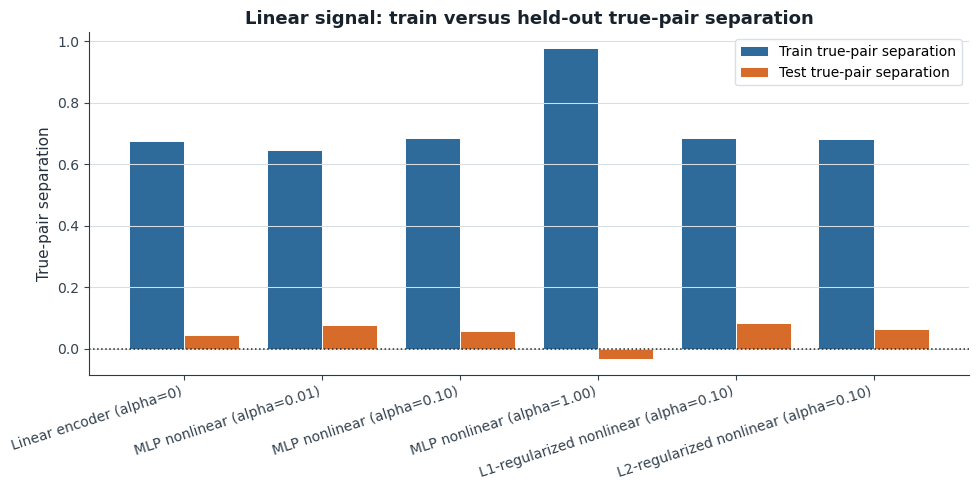

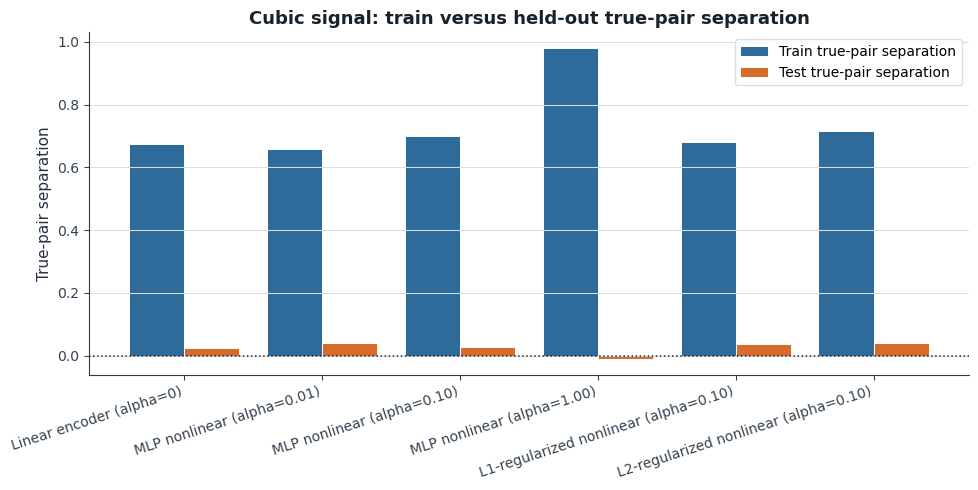

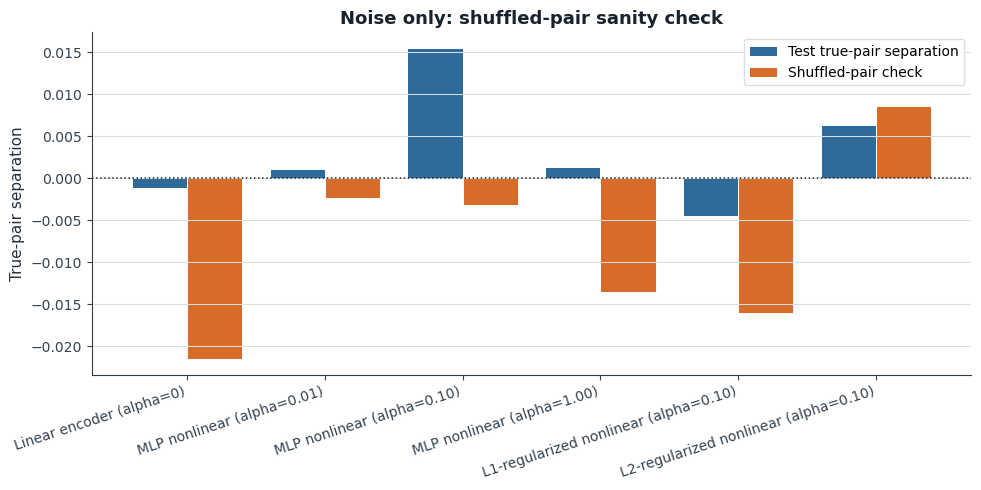

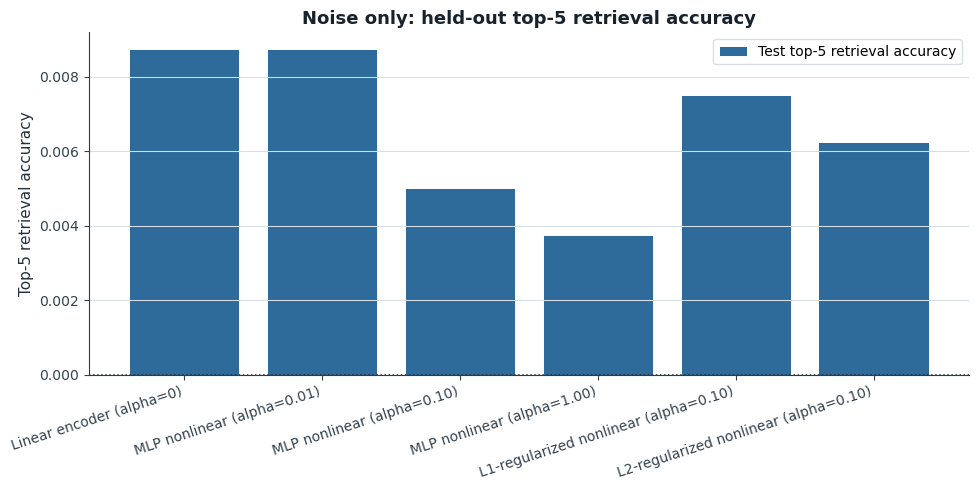

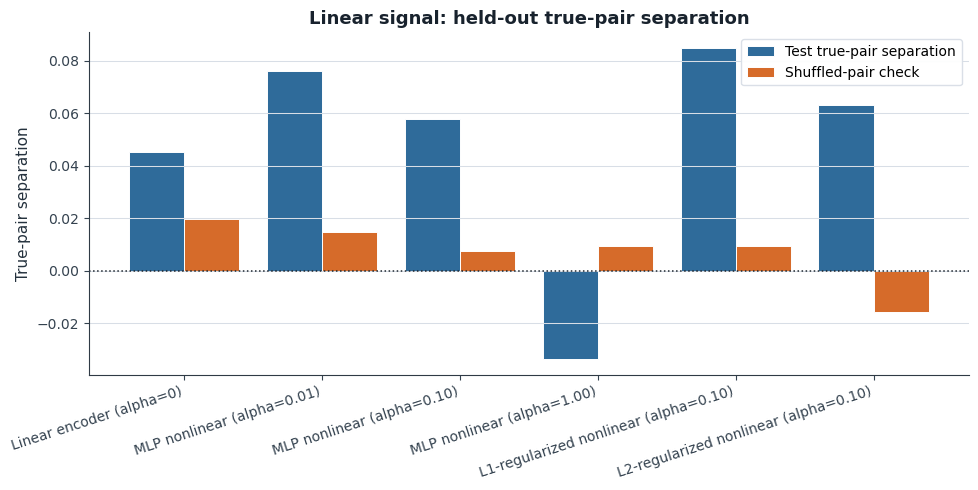

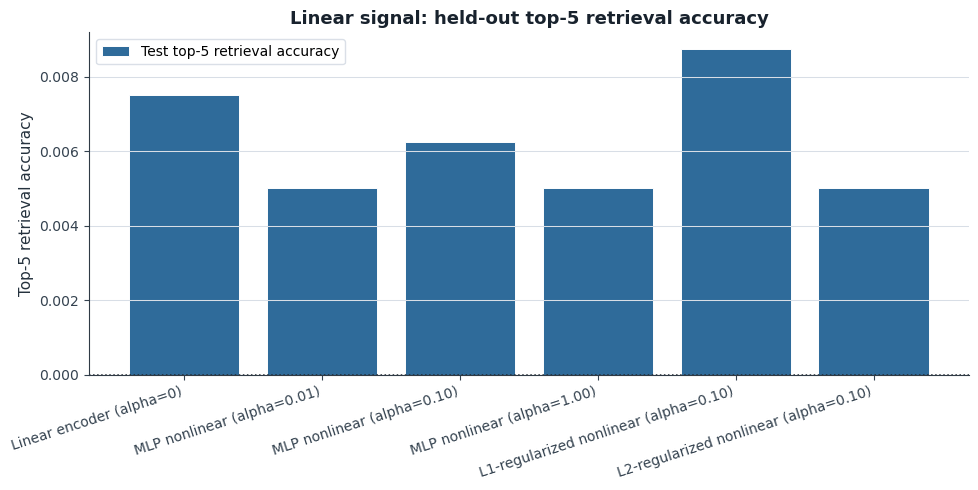

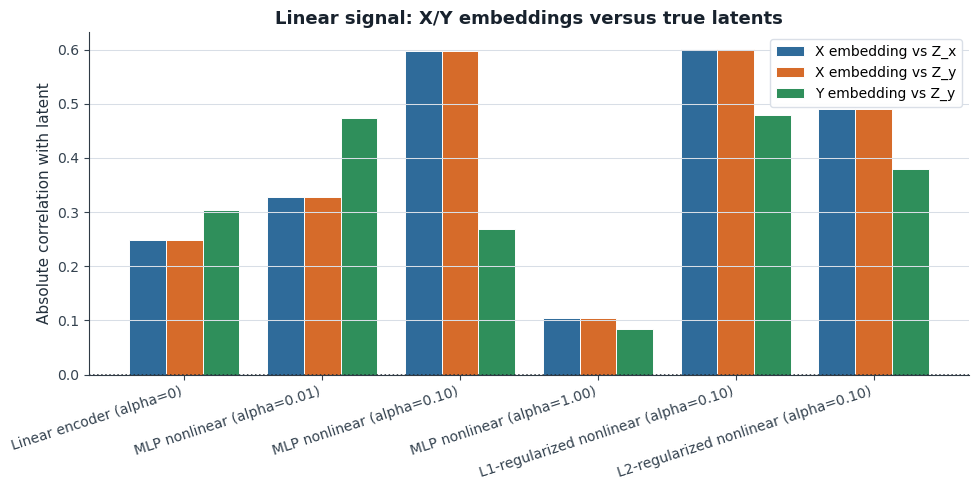

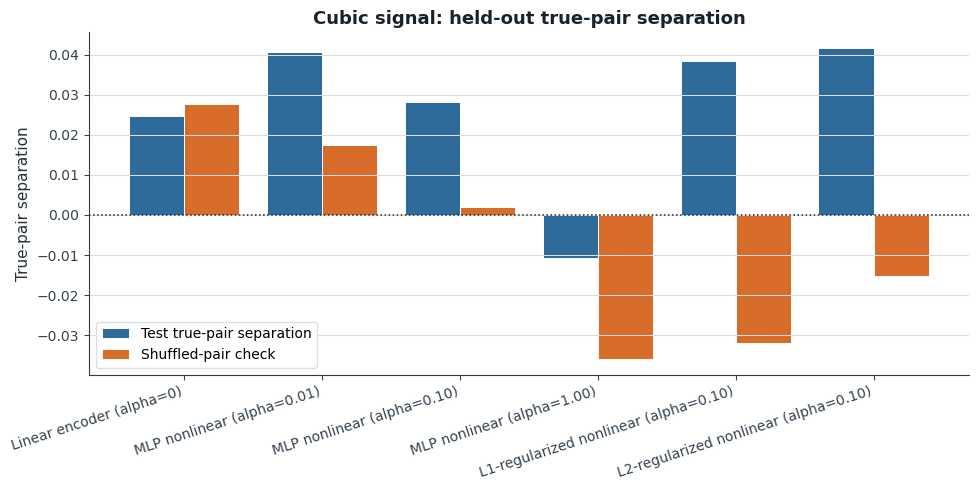

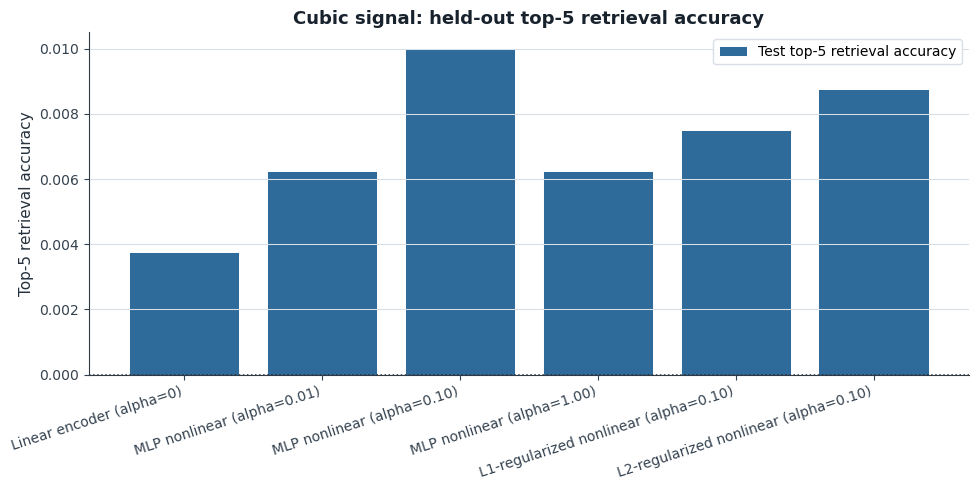

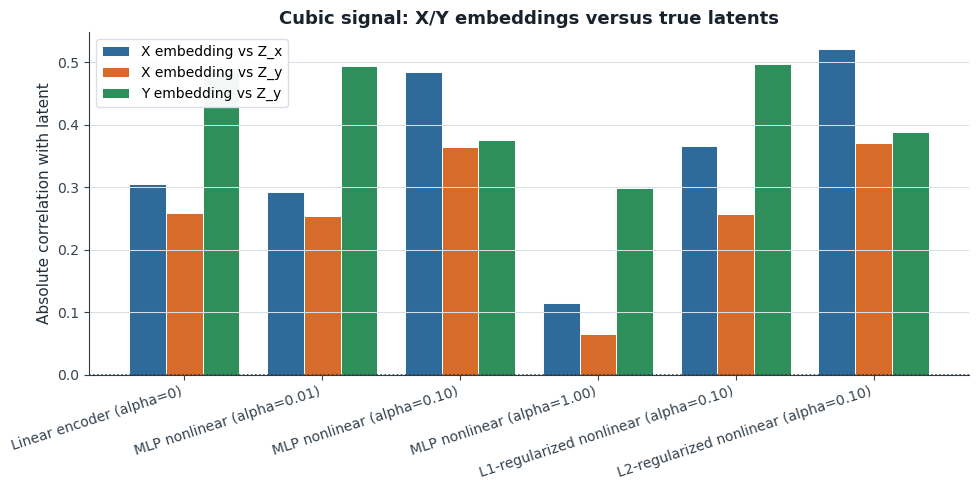

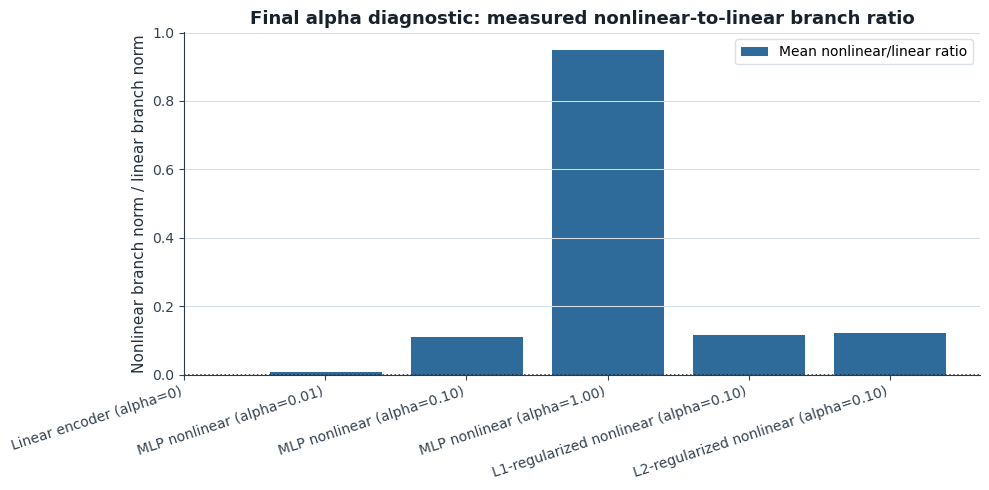

PosixPath('/Users/b4her/Desktop/git-repos/Remote/utssrp-cca-contrastive-encoders/reports/report-plots/final-alpha-diagnostic-measured-nonlinear-to-linear-branch-ratio.png')

In [50]:
for setting_name in ["Noise only", "Linear signal", "Cubic signal"]:
    plot_train_test_separation_by_setting(
        results,
        setting=setting_name,
        save_dir=PLOT_DIR,
    )

plot_metric_by_config(
    results,
    setting="Noise only",
    metrics=[
        "test_pair_separation",
        "shuffled_pair_separation",
    ],
    title="Noise only: shuffled-pair sanity check",
    ylabel="True-pair separation",
    save_dir=PLOT_DIR,
)
plot_top5_retrieval_by_setting(
    results,
    setting="Noise only",
    save_dir=PLOT_DIR,
)

for setting_name in ["Linear signal", "Cubic signal"]:
    plot_metric_by_config(
        results,
        setting=setting_name,
        metrics=[
            "test_pair_separation",
            "shuffled_pair_separation",
        ],
        title=f"{setting_name}: held-out true-pair separation",
        ylabel="True-pair separation",
        save_dir=PLOT_DIR,
    )

    plot_top5_retrieval_by_setting(
        results,
        setting=setting_name,
        save_dir=PLOT_DIR,
    )

    plot_signal_recovery_by_config(
        results,
        setting=setting_name,
        title=f"{setting_name}: X/Y embeddings versus true latents",
        save_dir=PLOT_DIR,
    )

plot_metric_by_config(
    results,
    setting="Cubic signal",
    metrics=[
        "mean_nonlinear_to_linear_ratio",
    ],
    title="Final alpha diagnostic: measured nonlinear-to-linear branch ratio",
    ylabel="Nonlinear branch norm / linear branch norm",
    save_dir=PLOT_DIR,
)


## 7. Branch history and similarity heatmaps

This section retrains the residual models on both the linear-signal and cubic-signal datasets so we can inspect training dynamics, not just final metrics.

The branch-history plot tracks:

```text
|| nonlinear branch || / || linear branch ||
```

over epochs. The heatmap plots `S = z_x z_y^T` for a small held-out batch. A clear bright diagonal means the model gives true X/Y pairs higher similarity than mismatched pairs. These figures are saved to `reports/report-plots/`.


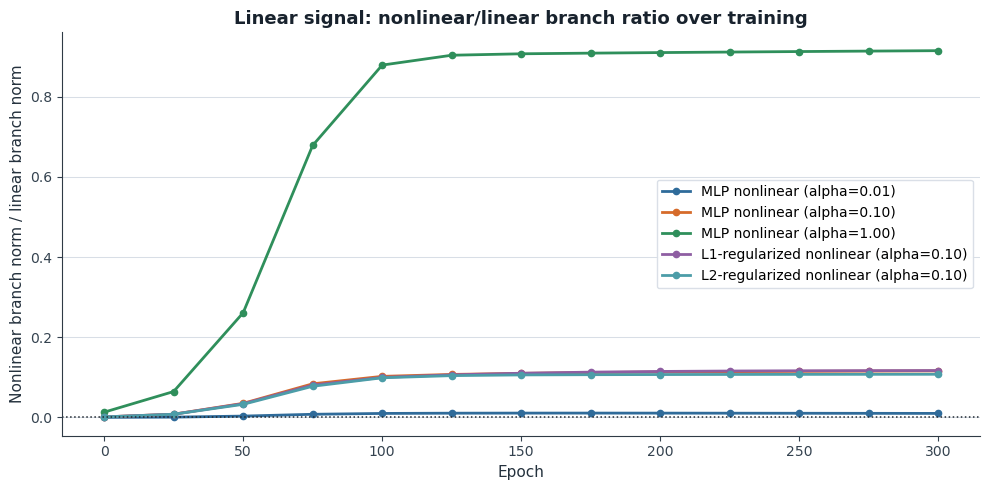

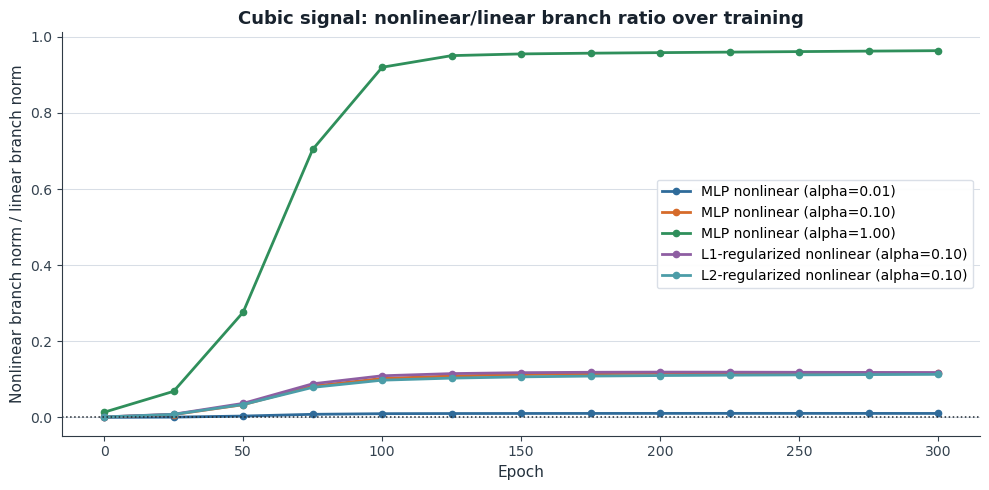

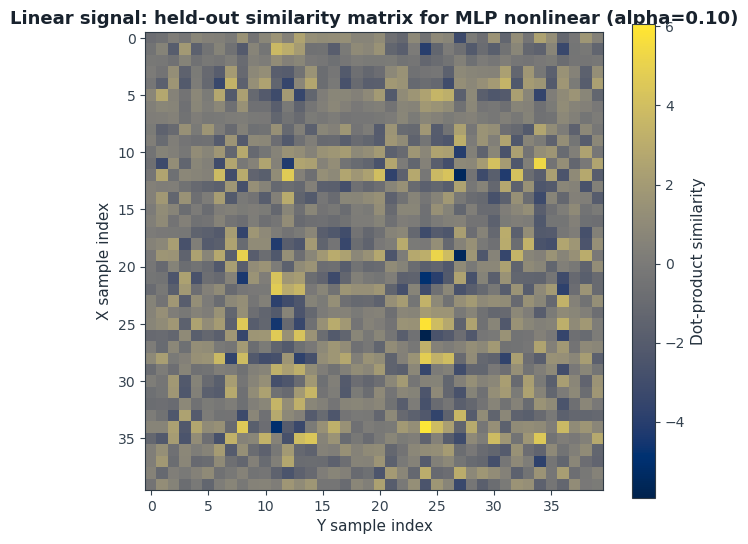

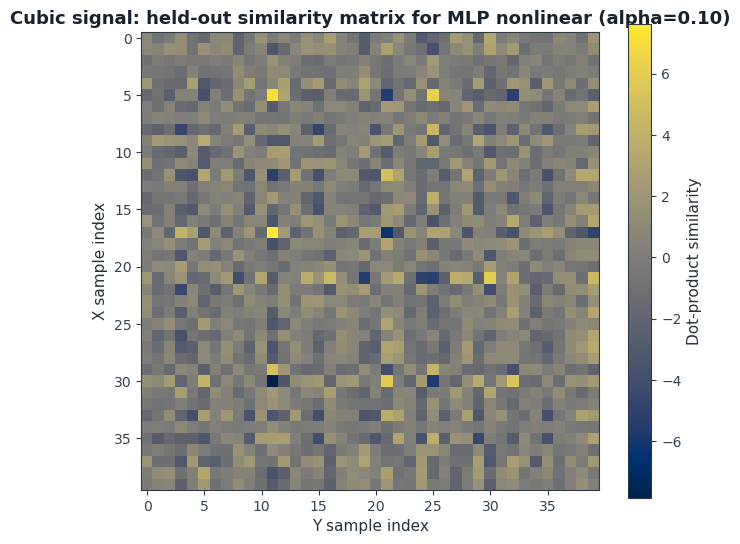

In [51]:
diagnostic_datasets = make_experiment_datasets(
    seed=GLOBAL_SEED,
    n_train=160,
    n_test=800,
    p=P_DIM,
    q=Q_DIM,
    signal_strength=2.0,
    noise_std=1.0,
)

diagnostic_configs = [
    config for config in configs
    if config.architecture == "residual"
]

diagnostic_settings = ["Linear signal", "Cubic signal"]
diagnostic_runs = {}
all_history_frames = []

for setting_index, setting_name in enumerate(diagnostic_settings):
    diagnostic_runs[setting_name] = {}
    setting_history_frames = []

    for config_index, config in enumerate(diagnostic_configs):
        run = train_one_model_with_artifacts(
            dataset=diagnostic_datasets[setting_name],
            config=config,
            seed=GLOBAL_SEED + 200 + 100 * setting_index + config_index,
            device=DEVICE,
            standardize=True,
            history_interval=25,
        )
        diagnostic_runs[setting_name][config.name] = run

        history = pd.DataFrame(run.history)
        history["setting"] = setting_name
        history["config"] = config.name
        setting_history_frames.append(history)
        all_history_frames.append(history)

    setting_branch_history = pd.concat(setting_history_frames, ignore_index=True)
    plot_branch_ratio_history(
        setting_branch_history,
        title=f"{setting_name}: nonlinear/linear branch ratio over training",
        save_dir=PLOT_DIR,
    )

selected_heatmap_model = "MLP nonlinear (alpha=0.10)"

for setting_name in diagnostic_settings:
    heatmap_run = diagnostic_runs[setting_name][selected_heatmap_model]
    plot_similarity_heatmap(
        heatmap_run.z_x_test,
        heatmap_run.z_y_test,
        n=40,
        title=f"{setting_name}: held-out similarity matrix for {selected_heatmap_model}",
        save_dir=PLOT_DIR,
    )

branch_history = pd.concat(all_history_frames, ignore_index=True)


## 8. Alpha sweep

This tests a denser alpha grid:

```text
alpha = [0.0, 0.01, 0.03, 0.1, 0.3, 1.0]
```

The plot asks whether there is a useful middle range where the nonlinear correction is strong enough to help but not so strong that it overfits or destabilizes. The figure is saved to `reports/report-plots/`.


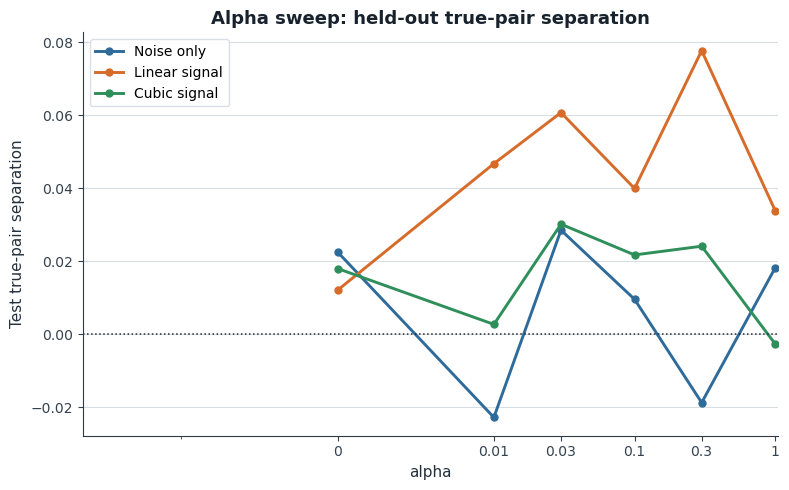

,Dataset,Model,Alpha,Test true-pair separation,Shuffled-pair check,Test top-5 retrieval accuracy,X signal recovery,X recovery of paired Y latent,Y signal recovery,X probe R^2 for Z_x,X probe R^2 for Z_y,Y probe R^2 for Z_y,Mean nonlinear/linear ratio
0,Noise only,MLP nonlinear (alpha=0.00),0.00,0.0226,-0.0343,0.0075,NaN,NaN,NaN,NaN,NaN,NaN,0.0000
1,Linear signal,MLP nonlinear (alpha=0.00),0.00,0.0121,-0.0236,0.0038,0.4197,0.4197,0.2307,0.0708,0.0708,-0.2893,0.0000
2,Cubic signal,MLP nonlinear (alpha=0.00),0.00,0.0180,-0.0177,0.0050,0.2463,0.1881,0.3107,-0.1070,-0.1015,0.0124,0.0000
3,Noise only,MLP nonlinear (alpha=0.01),0.01,-0.0227,0.0065,0.0025,NaN,NaN,NaN,NaN,NaN,NaN,0.0091
4,Linear signal,MLP nonlinear (alpha=0.01),0.01,0.0468,0.0094,0.0075,0.4869,0.4869,0.2989,0.2958,0.2958,-0.1259,0.0107
5,Cubic signal,MLP nonlinear (alpha=0.01),0.01,0.0027,0.0078,0.0062,0.4099,0.3532,0.2653,0.1413,0.0420,0.0860,0.0109
6,Noise only,MLP nonlinear (alpha=0.03),0.03,0.0286,-0.0106,0.0112,NaN,NaN,NaN,NaN,NaN,NaN,0.0317
7,Linear signal,MLP nonlinear (alpha=0.03),0.03,0.0608,-0.0318,0.0050,0.3049,0.3049,0.5001,-0.1451,-0.1451,0.1474,0.0354
8,Cubic signal,MLP nonlinear (alpha=0.03),0.03,0.0302,0.0302,0.0088,0.3903,0.3444,0.2154,0.1069,0.0216,-0.0069,0.0345
9,Noise only,MLP nonlinear (alpha=0.10),0.10,0.0096,-0.0034,0.0050,NaN,NaN,NaN,NaN,NaN,NaN,0.1210


In [52]:
alpha_sweep_results = run_alpha_sweep(
    seed=GLOBAL_SEED + 500,
    device=DEVICE,
    alphas=[0.0, 0.01, 0.03, 0.1, 0.3, 1.0],
    epochs=300,
    n_train=160,
    n_test=800,
    p=P_DIM,
    q=Q_DIM,
    signal_strength=2.0,
    noise_std=1.0,
)

plot_alpha_sweep_curve(
    alpha_sweep_results,
    metric="test_pair_separation",
    title="Alpha sweep: held-out true-pair separation",
    save_dir=PLOT_DIR,
)

display(
    friendly_results_table(
        alpha_sweep_results[
            [
                "setting",
                "config",
                "nonlinear_scale",
                "test_pair_separation",
                "shuffled_pair_separation",
                "test_top5_pair_match_accuracy",
                "x_signal_recovery",
                "x_related_signal_recovery",
                "y_signal_recovery",
                "x_probe_r2_z_x",
                "x_probe_r2_z_y",
                "y_probe_r2_z_y",
                "mean_nonlinear_to_linear_ratio",
            ]
        ].round(4)
    )
)


## 9. Signal strength / noise sweep

This sweep varies:

```text
signal_strength_values = [1.0, 2.0, 3.0, 5.0]
noise_std_values = [0.25, 0.5, 1.0, 2.0]
```

The x-axis is `signal_strength / noise_std`. If all models fail at low ratios and improve at high ratios, then the issue may be weak signal rather than the encoder architecture. The figure is saved to `reports/report-plots/`.


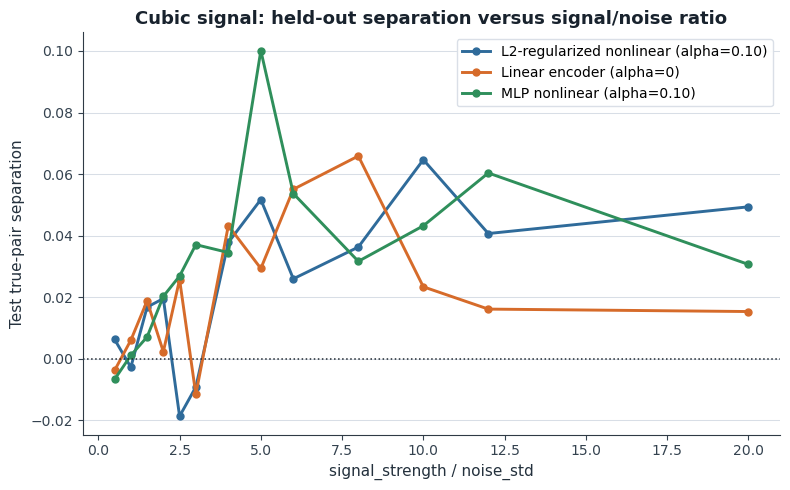

,Dataset,Model,signal_strength,noise_std,signal_to_noise,Test true-pair separation,Shuffled-pair check,Test top-5 retrieval accuracy,X signal recovery,X recovery of paired Y latent,Y signal recovery,X probe R^2 for Z_x,X probe R^2 for Z_y,Y probe R^2 for Z_y
0,Cubic signal,Linear encoder (alpha=0),1.0,0.25,4.0,0.0654,-0.0001,0.0150,0.6997,0.5710,0.6151,0.3426,0.1815,0.2584
1,Cubic signal,MLP nonlinear (alpha=0.10),1.0,0.25,4.0,0.0480,0.0075,0.0100,0.7795,0.6331,0.2056,0.7309,0.4463,0.1397
2,Cubic signal,L2-regularized nonlinear (alpha=0.10),1.0,0.25,4.0,0.0584,-0.0089,0.0225,0.8389,0.6777,0.3640,0.8010,0.4688,0.3334
3,Cubic signal,Linear encoder (alpha=0),1.0,0.50,2.0,0.0096,0.0142,0.0050,0.4420,0.3861,0.1973,0.1769,0.1019,-0.2187
4,Cubic signal,MLP nonlinear (alpha=0.10),1.0,0.50,2.0,0.0193,-0.0075,0.0112,0.3644,0.3144,0.4041,-0.0109,-0.1097,0.1428
5,Cubic signal,L2-regularized nonlinear (alpha=0.10),1.0,0.50,2.0,0.0271,0.0013,0.0075,0.3592,0.3011,0.2150,0.0407,-0.0119,0.0473
6,Cubic signal,Linear encoder (alpha=0),1.0,1.00,1.0,-0.0178,-0.0151,0.0062,0.1331,0.0966,0.3427,-0.0304,0.0020,0.1097
7,Cubic signal,MLP nonlinear (alpha=0.10),1.0,1.00,1.0,0.0130,0.0028,0.0050,0.2078,0.1458,0.2738,0.0641,0.0215,0.0730
8,Cubic signal,L2-regularized nonlinear (alpha=0.10),1.0,1.00,1.0,0.0034,-0.0086,0.0062,0.2686,0.2134,0.3036,0.0355,0.0115,0.0618
9,Cubic signal,Linear encoder (alpha=0),1.0,2.00,0.5,-0.0038,0.0005,0.0100,0.0779,0.0657,0.0508,-0.0719,-0.0327,-0.0058


In [53]:
signal_noise_configs = [
    TrainConfig(
        name="Linear encoder (alpha=0)",
        architecture="linear",
        hidden_dim=0,
        nonlinear_scale=0.0,
        epochs=300,
    ),
    TrainConfig(
        name="MLP nonlinear (alpha=0.10)",
        architecture="residual",
        hidden_dim=16,
        nonlinear_scale=0.10,
        epochs=300,
    ),
    TrainConfig(
        name="L2-regularized nonlinear (alpha=0.10)",
        architecture="residual",
        hidden_dim=16,
        nonlinear_scale=0.10,
        l2_nonlinear=1e-4,
        epochs=300,
    ),
]

signal_noise_results = run_signal_noise_sweep(
    configs=signal_noise_configs,
    seed=GLOBAL_SEED + 900,
    device=DEVICE,
    signal_strength_values=[1.0, 2.0, 3.0, 5.0],
    noise_std_values=[0.25, 0.5, 1.0, 2.0],
    setting="Cubic signal",
    n_train=160,
    n_test=800,
    p=P_DIM,
    q=Q_DIM,
)

plot_signal_noise_sweep(
    signal_noise_results,
    metric="test_pair_separation",
    title="Cubic signal: held-out separation versus signal/noise ratio",
    save_dir=PLOT_DIR,
)

display(
    friendly_results_table(
        signal_noise_results[
            [
                "setting",
                "config",
                "signal_strength",
                "noise_std",
                "signal_to_noise",
                "test_pair_separation",
                "shuffled_pair_separation",
                "test_top5_pair_match_accuracy",
                "x_signal_recovery",
                "x_related_signal_recovery",
                "y_signal_recovery",
                "x_probe_r2_z_x",
                "x_probe_r2_z_y",
                "y_probe_r2_z_y",
            ]
        ].round(4)
    )
)


## 10. Deterministic relation with explicit SNR

This is a new experiment that does **not** replace the earlier latent-signal experiments.

The earlier datasets used hidden latents and then embedded the signal into noisy high-dimensional views:

```text
X = signal from Z_x + feature noise
Y = signal from Z_y + feature noise
```

Here we make the relation more direct:

```text
X ~ N(0, I)
Y_clean = f(X)
Y = Y_clean + epsilon
```

The first photo is the whiteboard version of this idea: for example, one can set `y_i = x_i^3 + epsilon_i`, with `epsilon_i ~ N(0, tau^2)`. Small `tau` keeps the points close to the deterministic curve; large `tau` makes the relation harder to recover.

The second photo gives the formal noise-control rule:

```text
SNR = Var(f(X)) / Var(epsilon)
```

So in code we choose:

```text
Var(epsilon) = Var(f(X)) / target_snr
```

We now test three noise regimes:

```text
low SNR       = 0.25   oracle PVE about 0.20
mid SNR       = 2.00   oracle PVE about 0.67
very high SNR = 20.00  oracle PVE about 0.95
```

The same photo explains why the oracle proportion of variance explained is:

```text
PVE(f) = SNR / (1 + SNR)
```

Interpretation: if the model fails at low SNR, the signal may simply be buried in noise. If it fails at very high SNR, the issue is more likely the architecture, objective, optimization, or evaluation setup.


In [54]:
# Use the same full model grid as the main experiment.
# This includes the linear baseline, all MLP alpha settings, and L1/L2 variants.
deterministic_configs = make_first_experiment_configs(epochs=300)

deterministic_snr_values = [0.25, 2.0, 20.0]
deterministic_snr_labels = {
    0.25: "low SNR",
    2.0: "mid SNR",
    20.0: "very high SNR",
}

deterministic_results = run_deterministic_relation_experiment(
    configs=deterministic_configs,
    seed=GLOBAL_SEED + 1300,
    device=DEVICE,
    relationships=["linear", "cubic"],
    snr_values=deterministic_snr_values,
    n_train=160,
    n_test=800,
    p=P_DIM,
    q=Q_DIM,
)

deterministic_results["snr_level"] = deterministic_results["target_snr"].map(
    deterministic_snr_labels
)

display(
    friendly_results_table(
        deterministic_results[
            [
                "setting",
                "relationship",
                "snr_level",
                "target_snr",
                "realized_snr",
                "oracle_pve",
                "config",
                "train_pair_separation",
                "test_pair_separation",
                "shuffled_pair_separation",
                "test_top5_pair_match_accuracy",
                "x_probe_r2_z_y",
                "y_probe_r2_z_y",
                "mean_nonlinear_to_linear_ratio",
            ]
        ].round(4)
    )
)


,Dataset,Deterministic relation,snr_level,Target SNR,Realized SNR,Oracle PVE,Model,Train true-pair separation,Test true-pair separation,Shuffled-pair check,Test top-5 retrieval accuracy,X probe R^2 for Z_y,Y probe R^2 for Z_y,Mean nonlinear/linear ratio
0,Deterministic linear,linear,low SNR,0.25,0.2498,0.1999,Linear encoder (alpha=0),0.6537,0.0997,0.0020,0.0162,-0.0211,-0.0679,NaN
1,Deterministic linear,linear,low SNR,0.25,0.2498,0.1999,MLP nonlinear (alpha=0.01),0.6829,0.1343,0.0211,0.0075,-0.0143,-0.0711,0.0109
2,Deterministic linear,linear,low SNR,0.25,0.2498,0.1999,MLP nonlinear (alpha=0.10),0.6974,0.1163,0.0294,0.0112,-0.0188,-0.0620,0.1187
3,Deterministic linear,linear,low SNR,0.25,0.2498,0.1999,MLP nonlinear (alpha=1.00),0.9752,0.0361,-0.0109,0.0038,-0.0238,-0.0778,0.8957
4,Deterministic linear,linear,low SNR,0.25,0.2498,0.1999,L1-regularized nonlinear (alpha=0.10),0.7209,0.1461,-0.0011,0.0088,-0.0101,-0.0730,0.1305
5,Deterministic linear,linear,low SNR,0.25,0.2498,0.1999,L2-regularized nonlinear (alpha=0.10),0.6745,0.1317,-0.0113,0.0075,-0.0143,-0.0741,0.1227
6,Deterministic linear,linear,mid SNR,2.00,1.9644,0.6627,Linear encoder (alpha=0),0.6639,0.3669,0.0097,0.0213,-0.0044,-0.0166,NaN
7,Deterministic linear,linear,mid SNR,2.00,1.9644,0.6627,MLP nonlinear (alpha=0.01),0.6878,0.4113,-0.0172,0.0238,-0.0034,-0.0192,0.0127
8,Deterministic linear,linear,mid SNR,2.00,1.9644,0.6627,MLP nonlinear (alpha=0.10),0.7240,0.3751,0.0089,0.0225,-0.0051,-0.0266,0.1261
9,Deterministic linear,linear,mid SNR,2.00,1.9644,0.6627,MLP nonlinear (alpha=1.00),0.9620,0.2340,0.0143,0.0088,-0.0311,-0.0484,0.9028


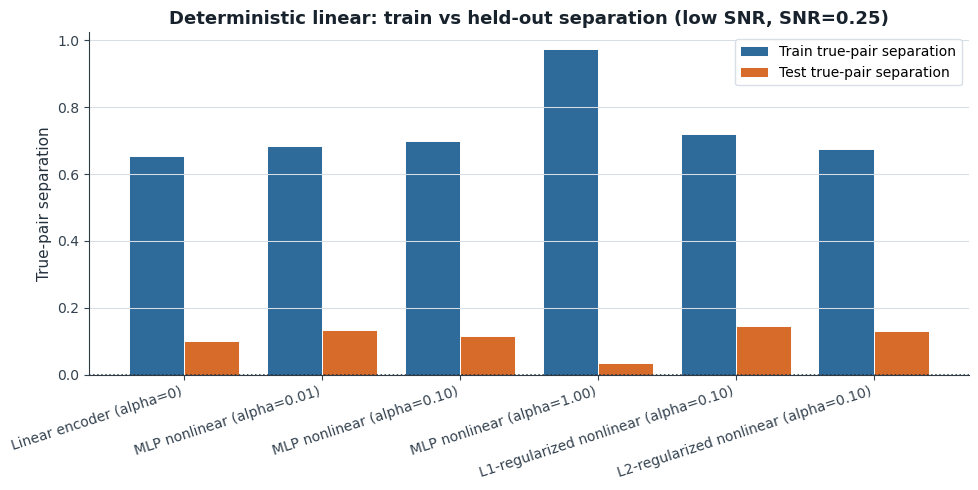

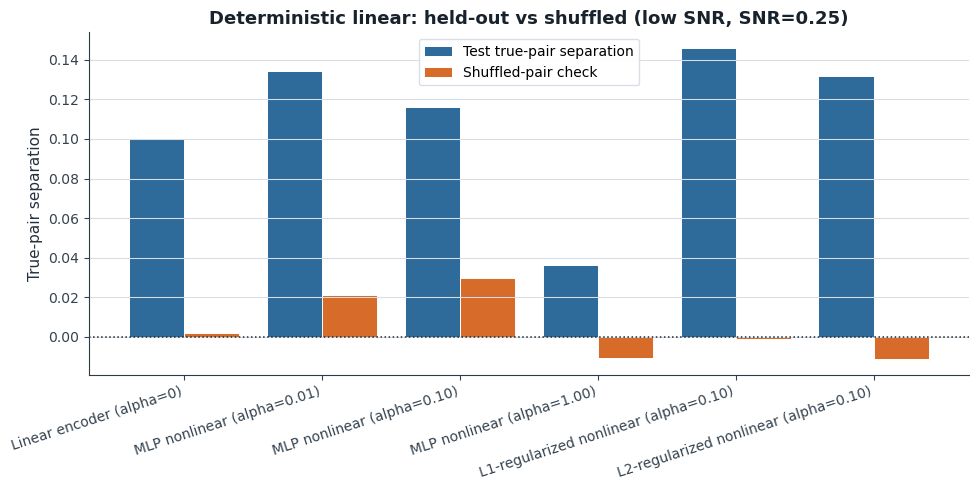

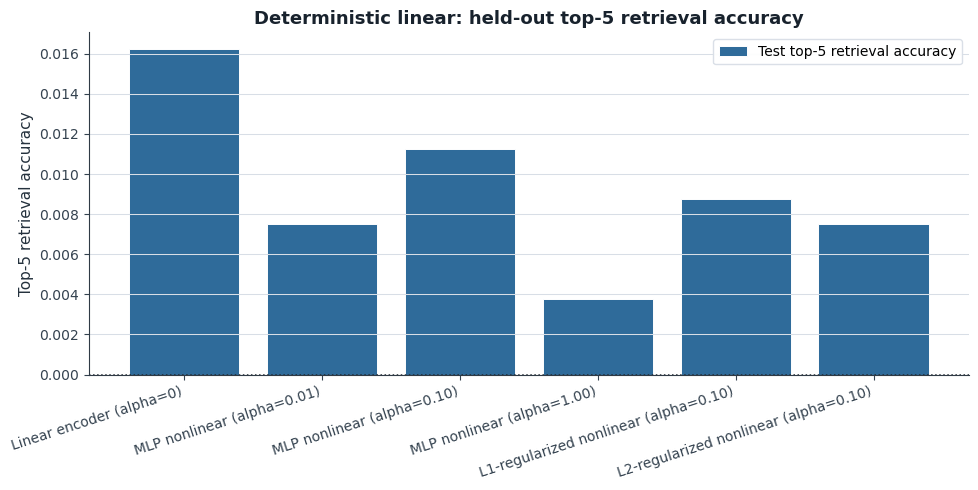

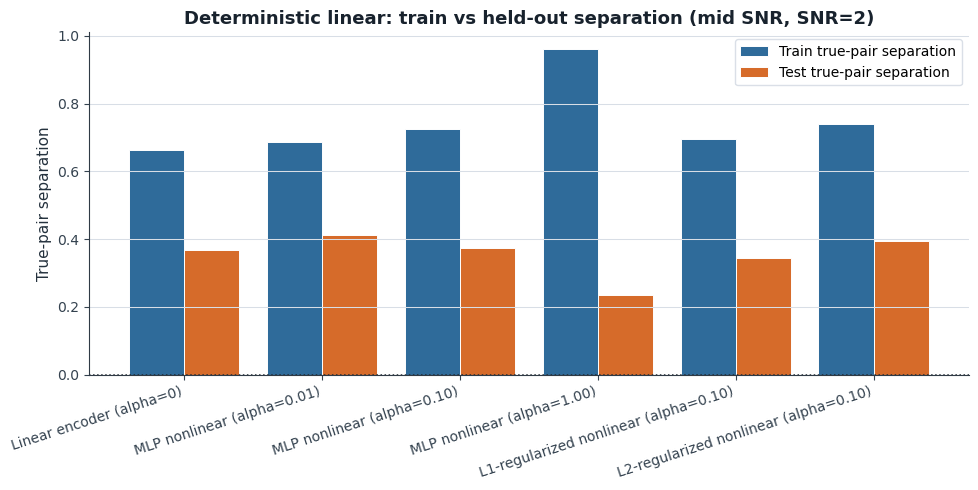

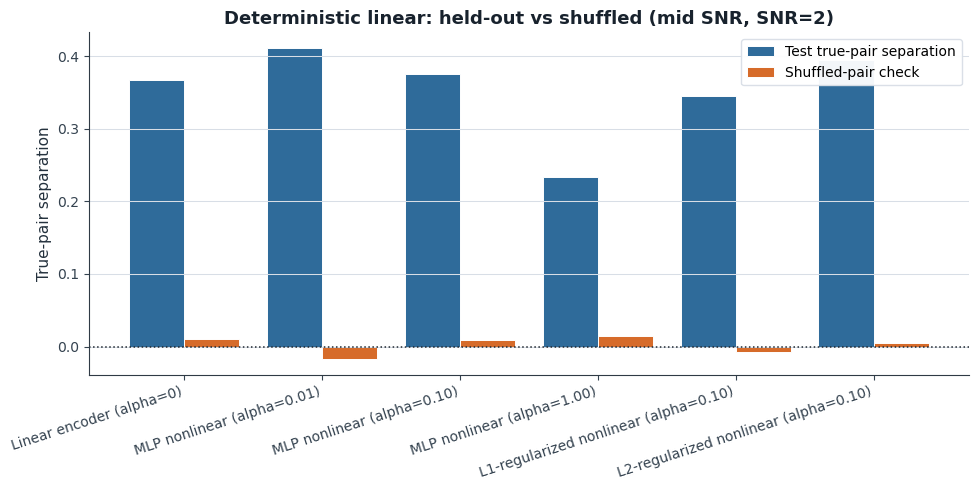

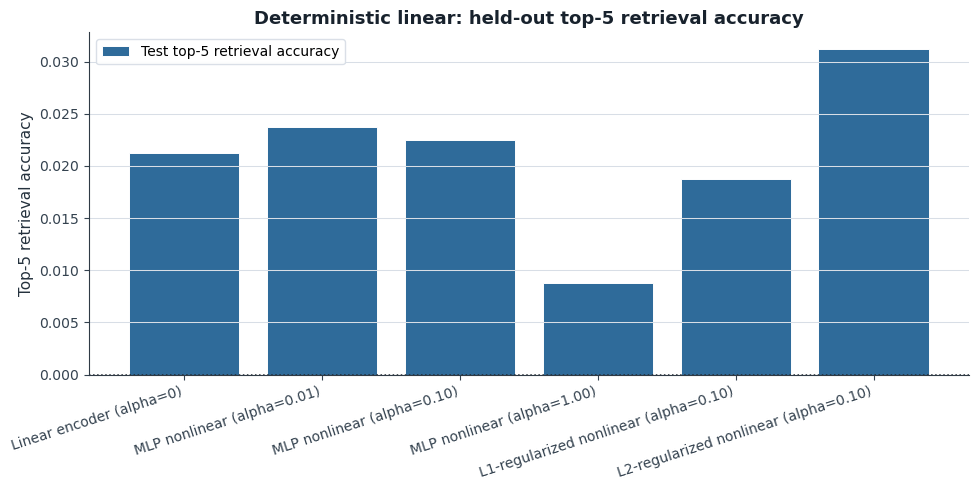

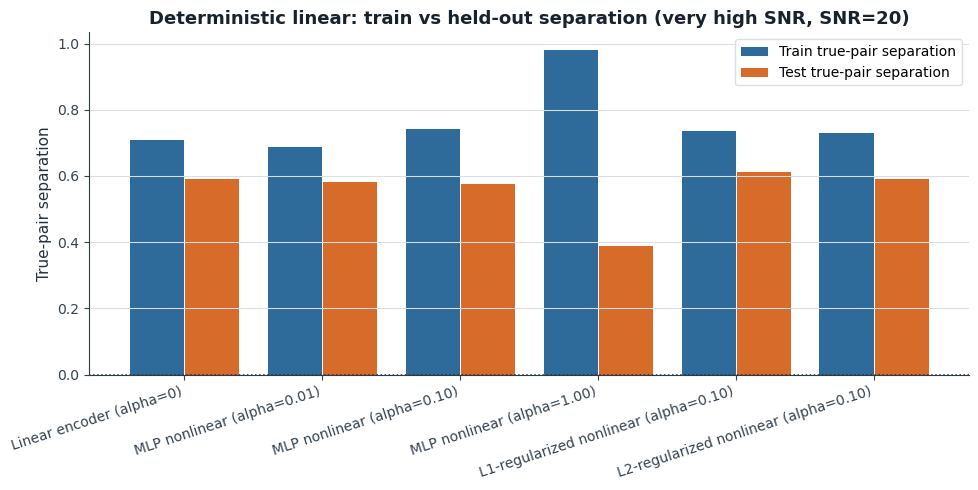

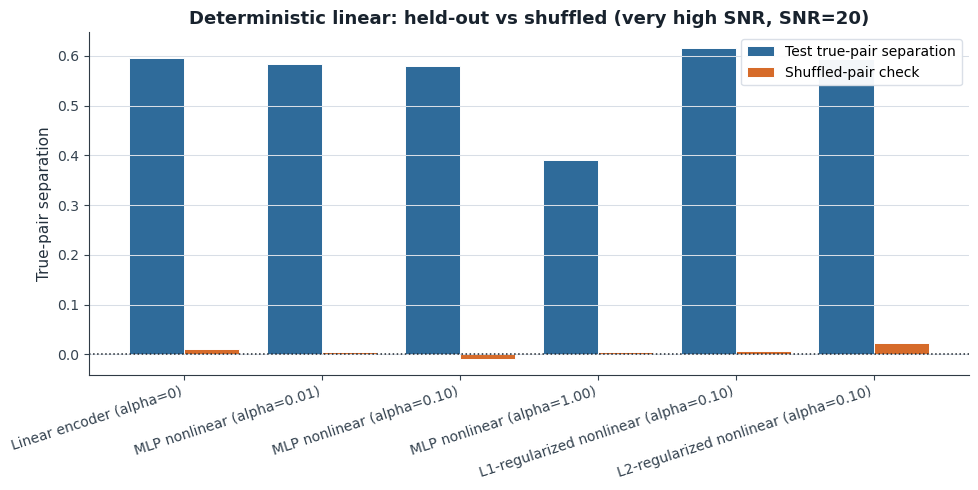

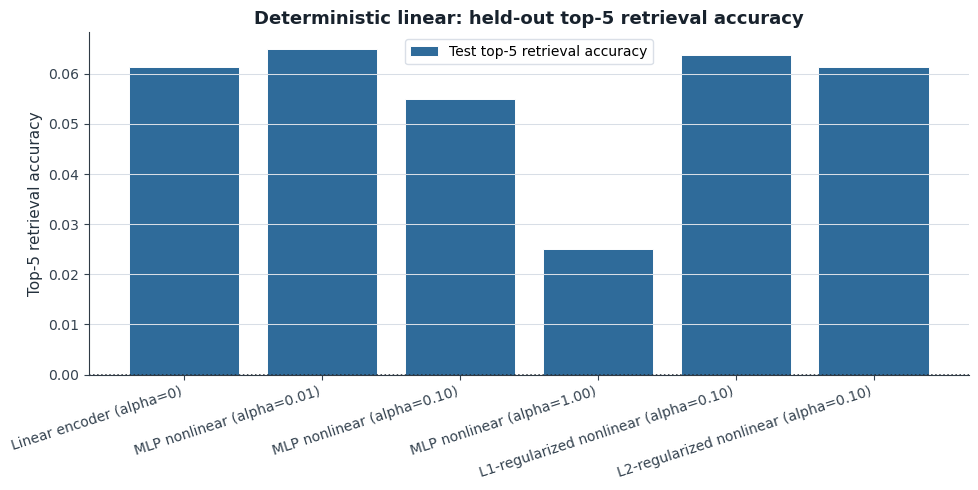

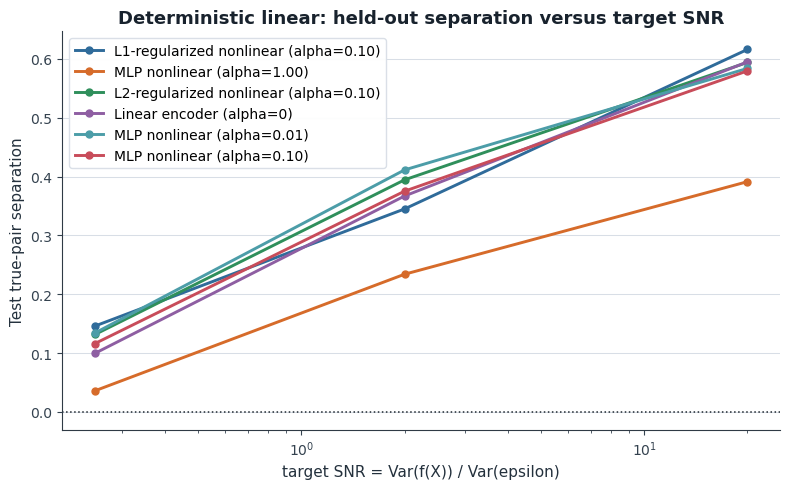

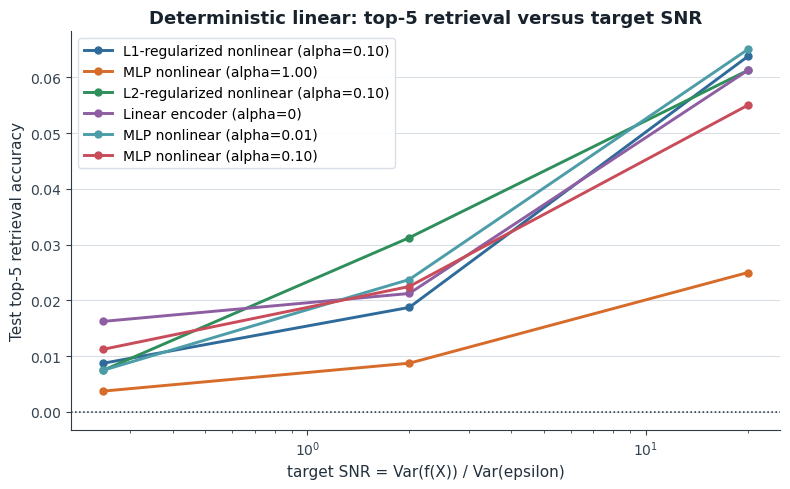

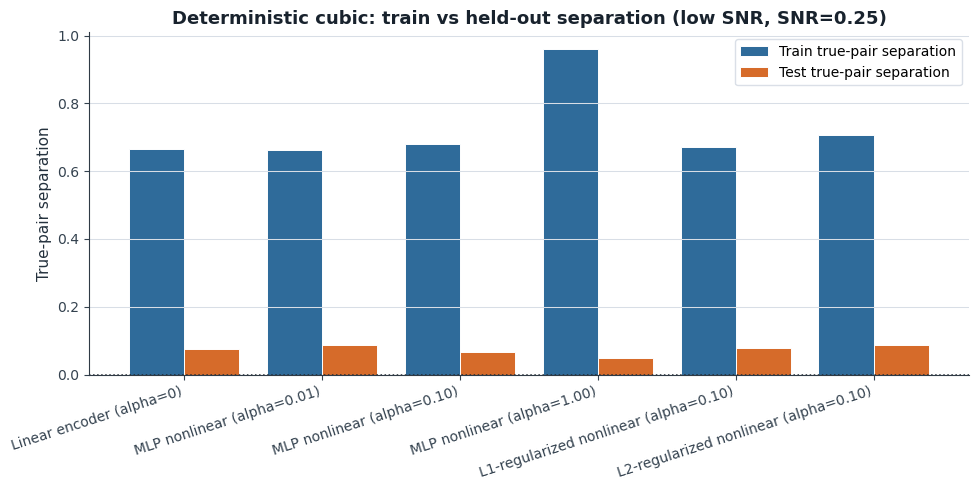

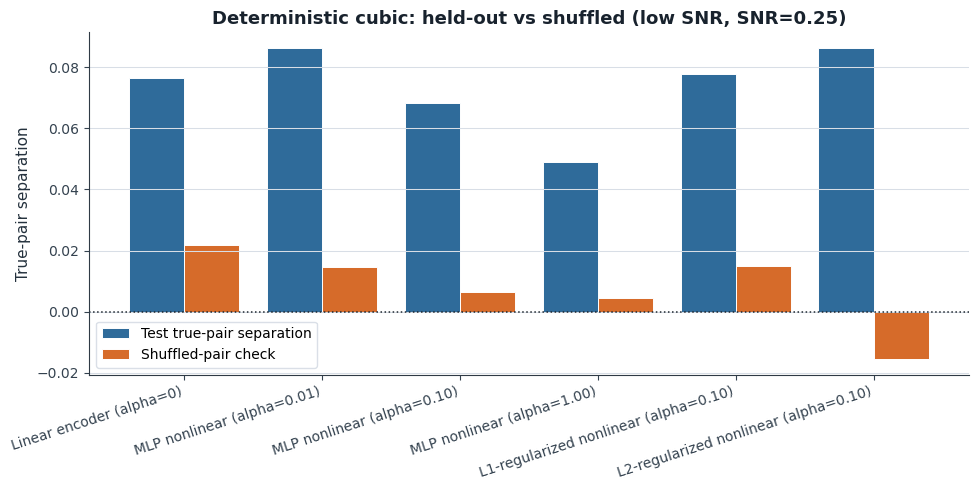

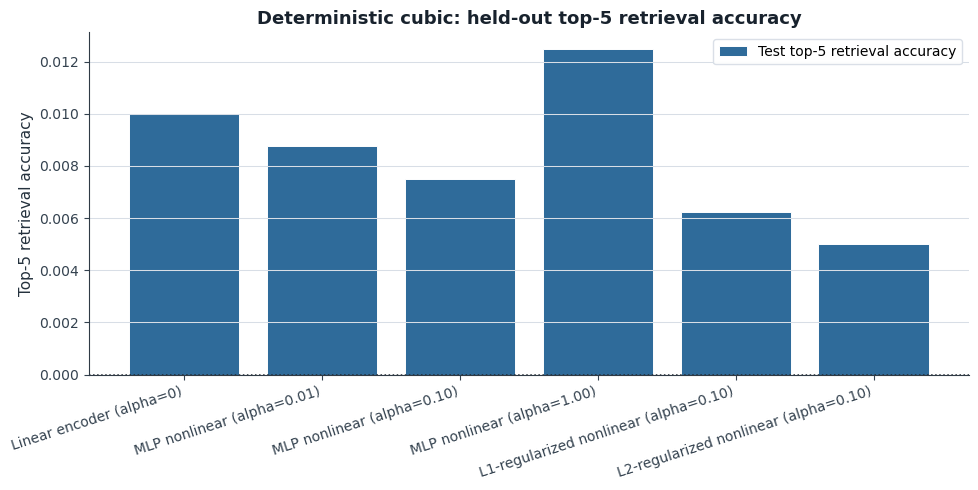

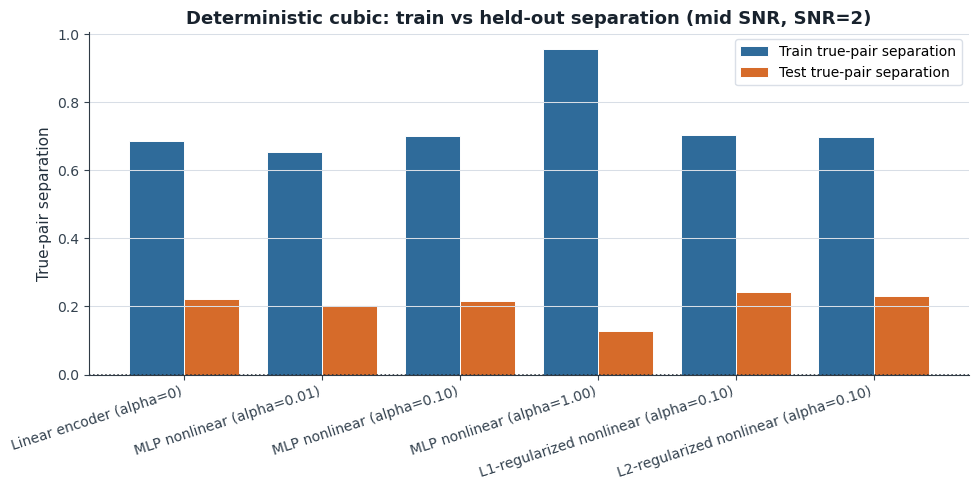

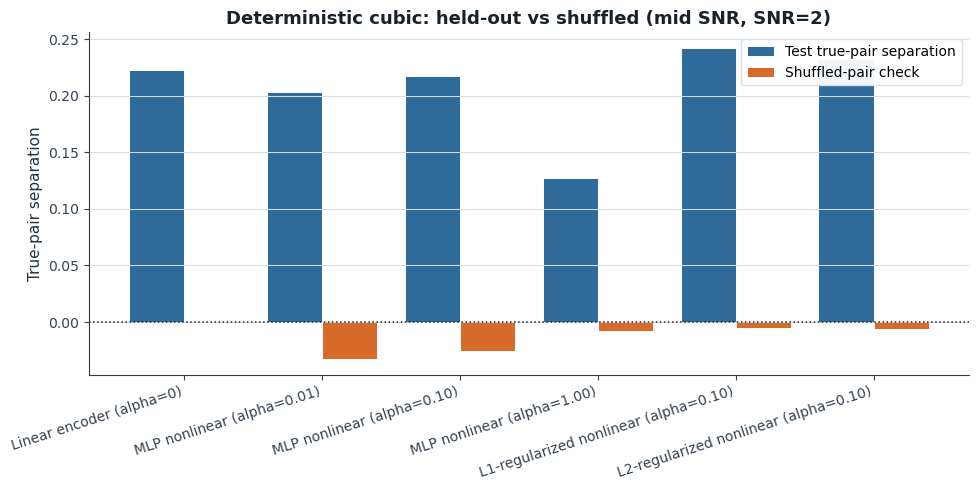

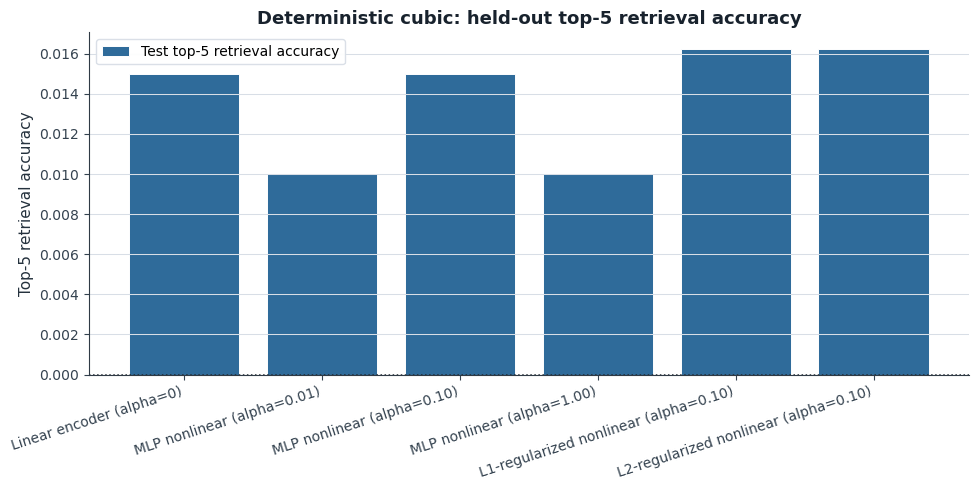

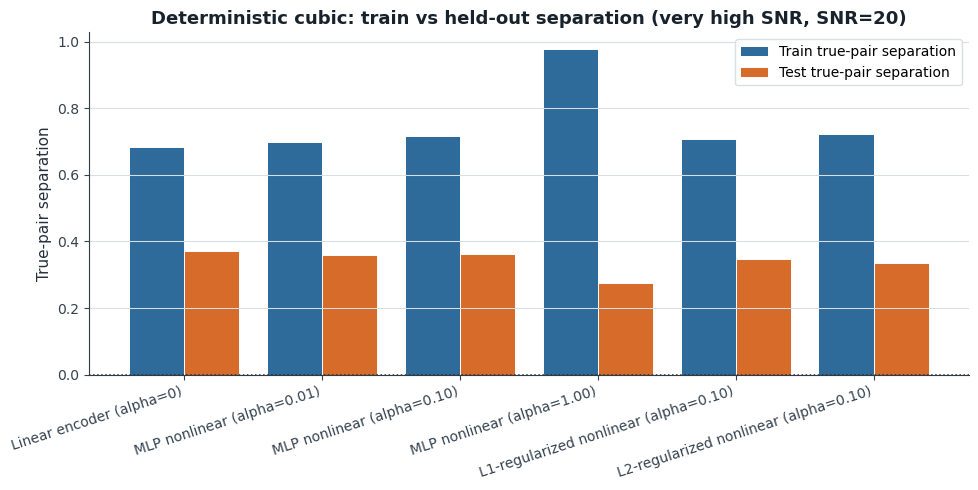

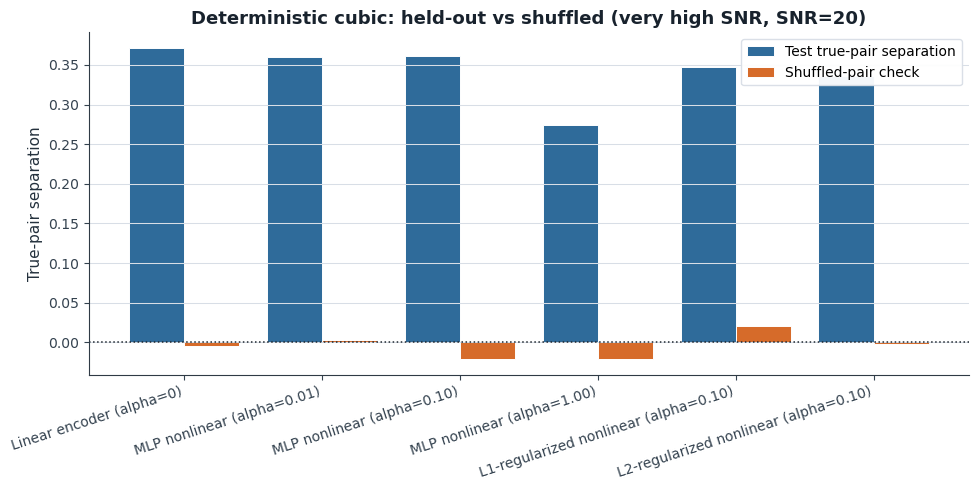

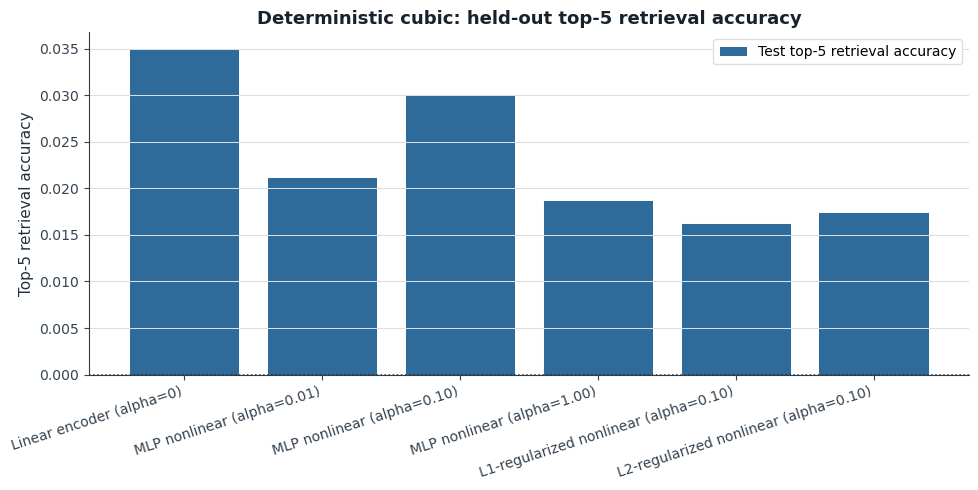

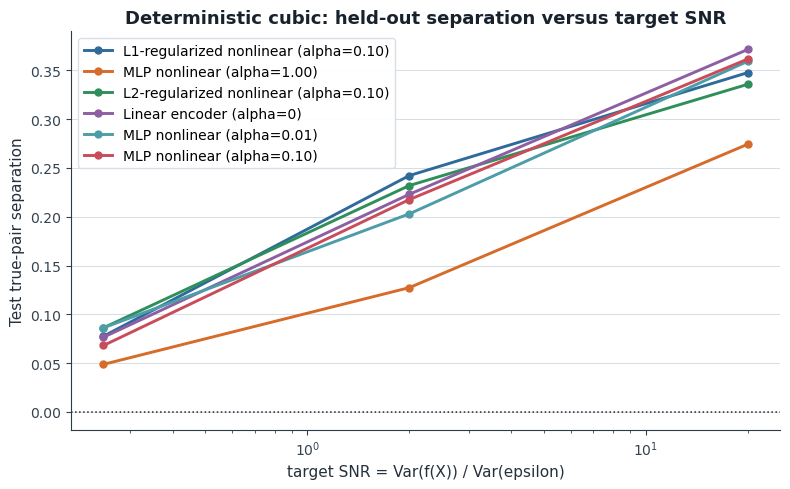

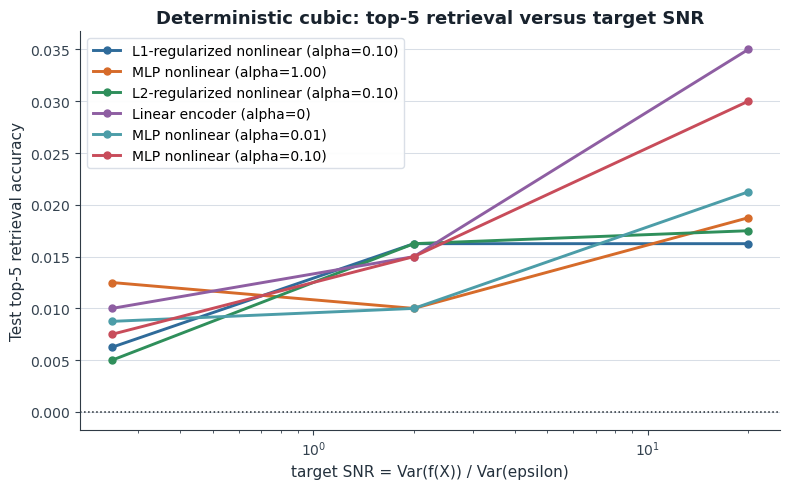

In [55]:
for relationship in ["linear", "cubic"]:
    setting_name = f"Deterministic {relationship}"

    for target_snr in deterministic_snr_values:
        snr_label = deterministic_snr_labels[target_snr]
        subset = deterministic_results[
            (deterministic_results["relationship"] == relationship)
            & (deterministic_results["target_snr"] == target_snr)
        ].copy()

        plot_metric_by_config(
            subset,
            setting=setting_name,
            metrics=["train_pair_separation", "test_pair_separation"],
            title=f"{setting_name}: train vs held-out separation ({snr_label}, SNR={target_snr:g})",
            ylabel="True-pair separation",
            save_dir=PLOT_DIR,
        )

        plot_metric_by_config(
            subset,
            setting=setting_name,
            metrics=["test_pair_separation", "shuffled_pair_separation"],
            title=f"{setting_name}: held-out vs shuffled ({snr_label}, SNR={target_snr:g})",
            ylabel="True-pair separation",
            save_dir=PLOT_DIR,
        )

        plot_top5_retrieval_by_setting(
            subset,
            setting=setting_name,
            save_dir=PLOT_DIR,
        )

    plot_deterministic_snr_sweep(
        deterministic_results,
        relationship=relationship,
        metric="test_pair_separation",
        title=f"{setting_name}: held-out separation versus target SNR",
        save_dir=PLOT_DIR,
    )

    plot_deterministic_snr_sweep(
        deterministic_results,
        relationship=relationship,
        metric="test_top5_pair_match_accuracy",
        title=f"{setting_name}: top-5 retrieval versus target SNR",
        save_dir=PLOT_DIR,
    )


### How to interpret results

- If SNR is high and the model still fails, that suggests an architecture/training/loss issue.
- If SNR is low and the model fails, that may simply mean the signal is too buried in noise.
- If your model’s ridge-probe R² approaches oracle_pve, that is very good. It means the embedding is recovering almost as much clean structure as theoretically possible under that noise level.

## 11. Deterministic held-out similarity matrices

This diagnostic visualizes the held-out similarity matrix:

```text
S = normalized(z_x_test) normalized(z_y_test)^T
```

Rows are held-out X samples and columns are held-out Y samples. A bright diagonal means the model gives each true pair higher similarity than mismatched pairs. A flat or messy matrix means the embeddings are not learning a clean pair structure.

By default, this cell uses the **mid SNR** deterministic tests and all models from the deterministic grid. To inspect low or very high SNR, change:

```python
deterministic_heatmap_snr_values = [0.25, 2.0, 20.0]
```

The final printed 10x10 table is a small numeric version of the same cosine-similarity matrix for one representative model.


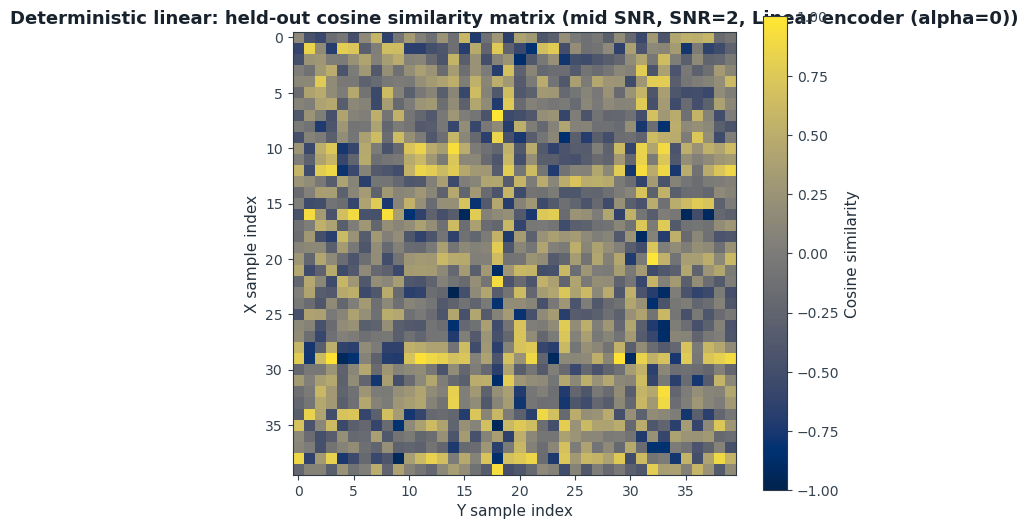

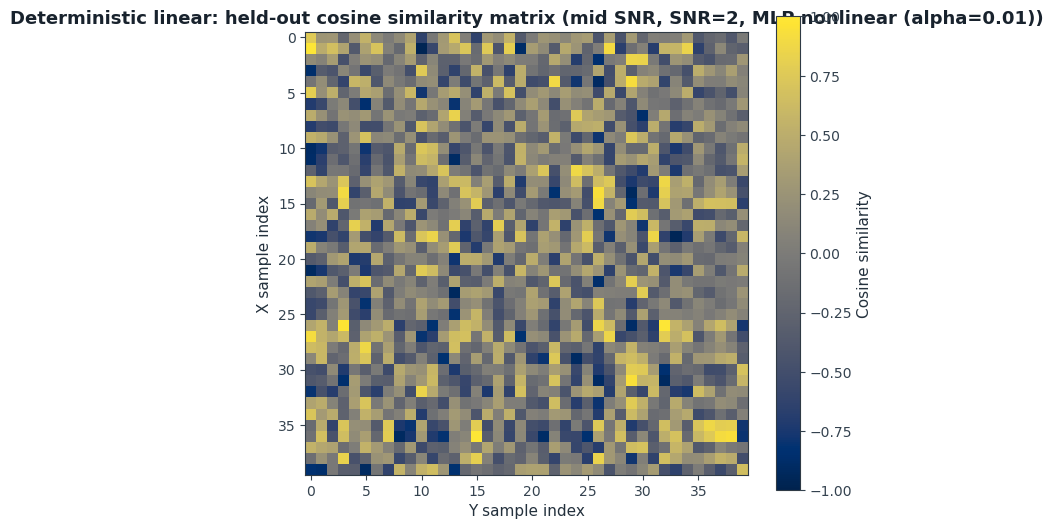

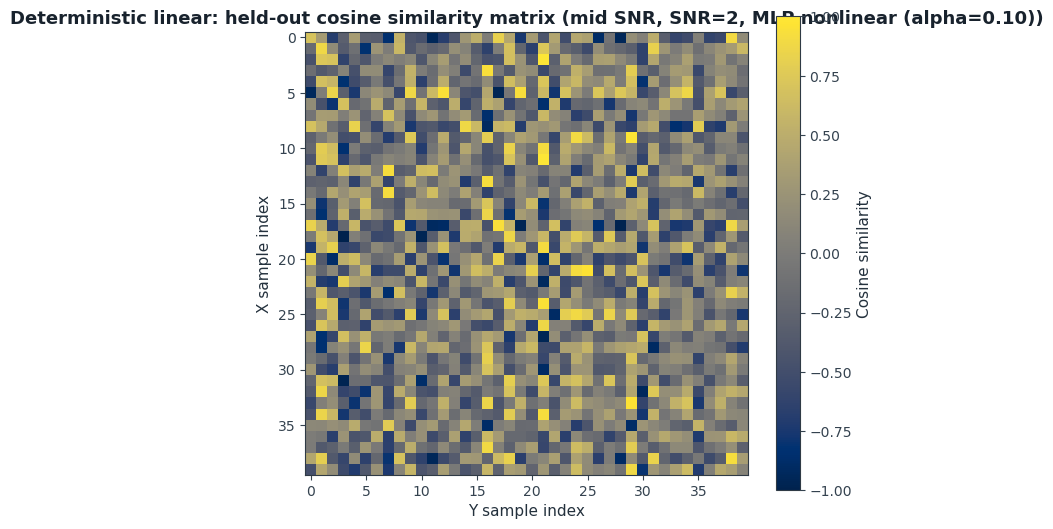

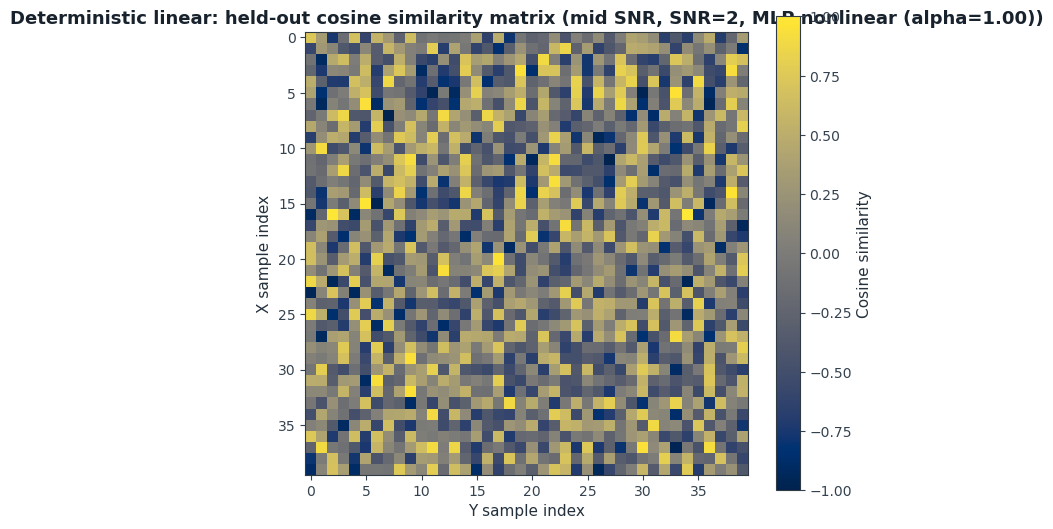

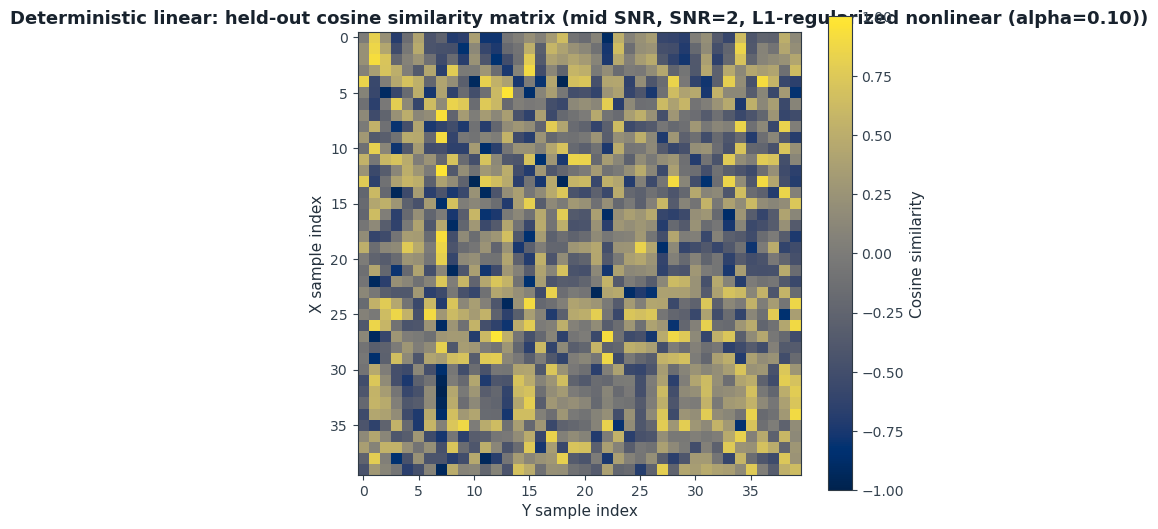

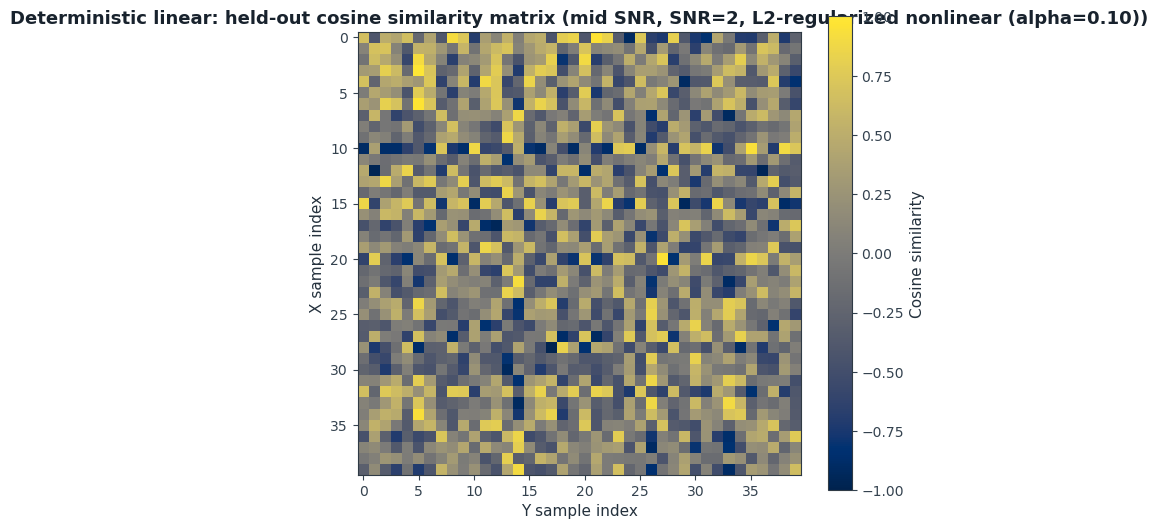

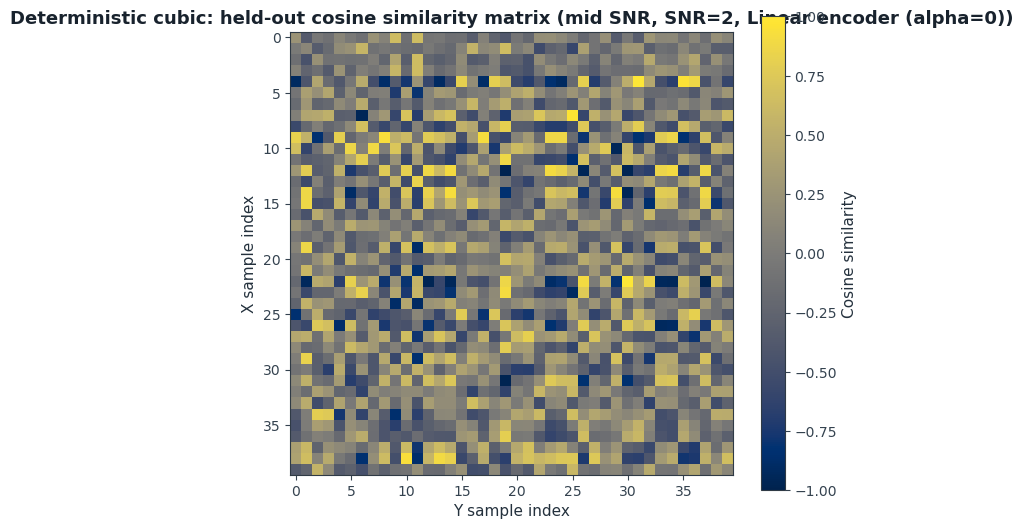

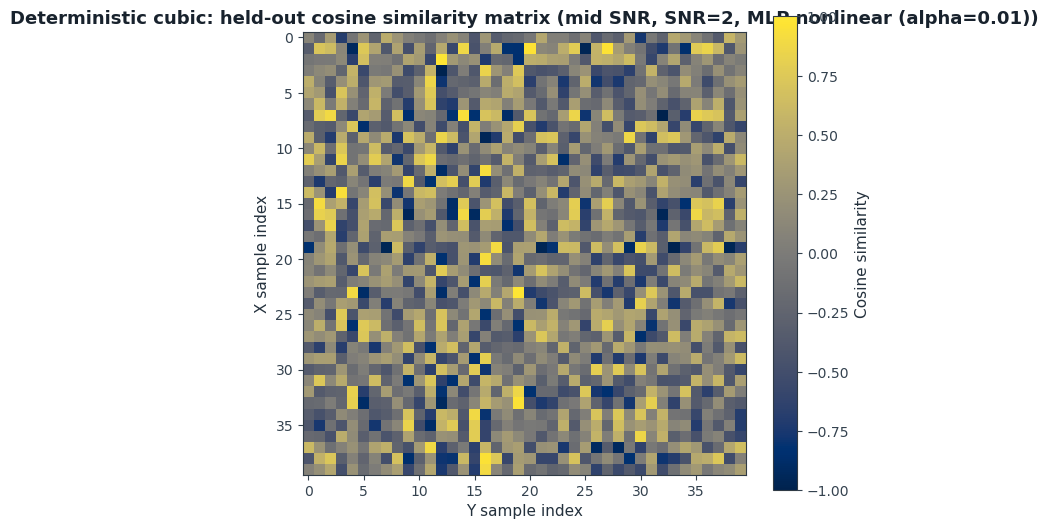

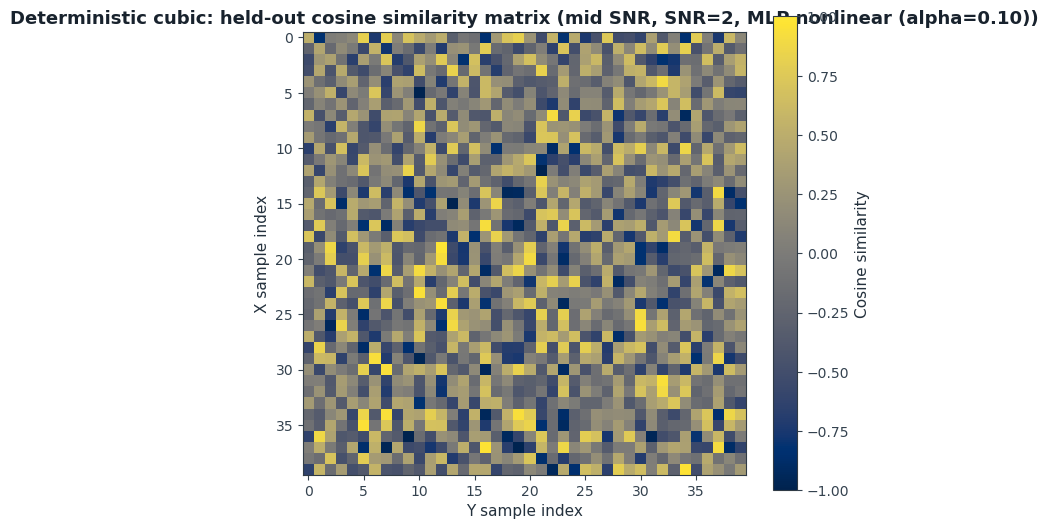

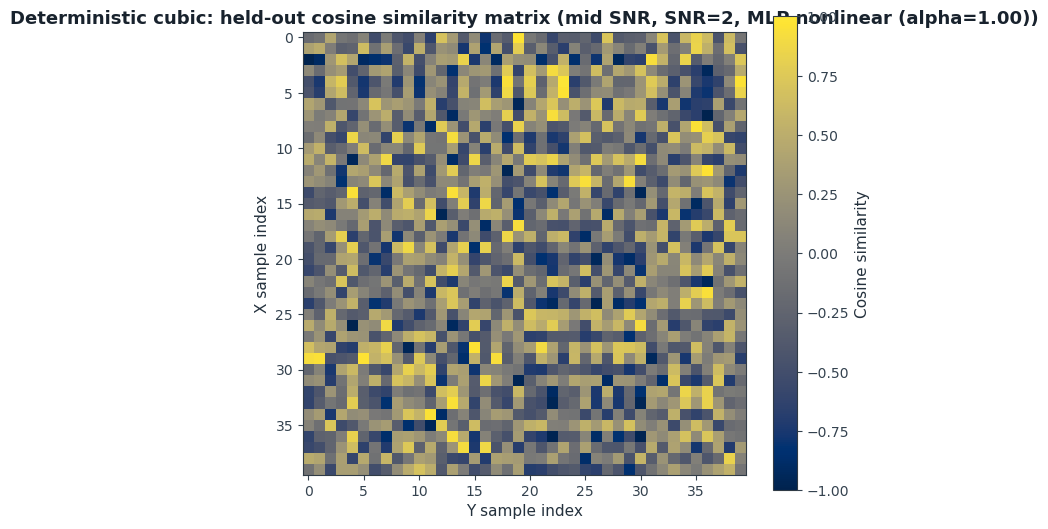

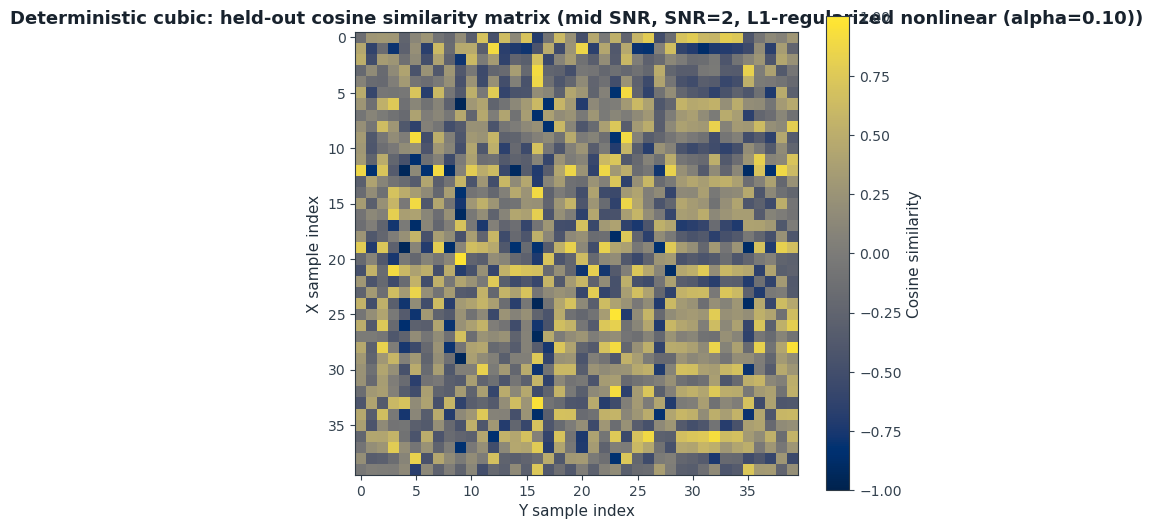

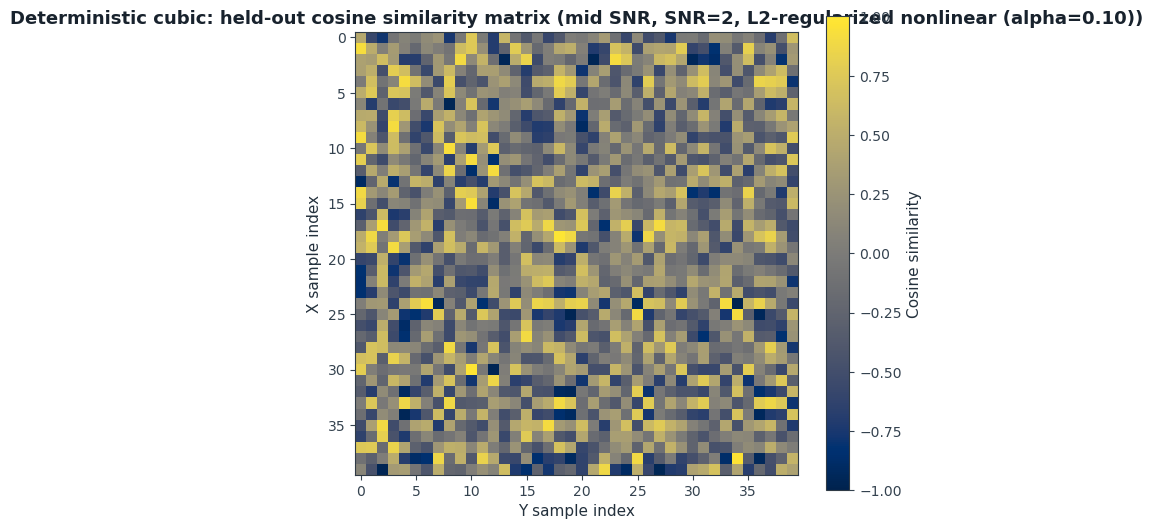

,Y0,Y1,Y2,Y3,Y4,Y5,Y6,Y7,Y8,Y9
X0,0.51,-0.82,0.02,0.05,0.14,0.82,-0.73,0.80,0.12,0.70
X1,-0.25,0.43,-0.19,0.16,-0.01,-0.56,0.55,-0.78,0.02,-0.16
X2,-0.54,0.28,0.38,-0.10,-0.67,0.36,-0.01,0.72,-0.69,-0.39
X3,-0.50,0.44,-0.43,0.47,-0.36,-0.53,-0.15,0.11,-0.46,-0.63
X4,0.26,-0.13,-0.29,0.17,0.35,-0.25,0.20,-0.66,0.40,0.37
X5,0.03,0.23,0.54,-0.58,0.15,-0.00,0.73,-0.59,0.26,0.04
X6,-0.23,0.09,-0.08,0.26,-0.25,0.06,0.37,-0.30,-0.19,0.30
X7,0.55,-0.45,0.14,-0.33,0.45,0.25,-0.52,0.40,0.41,0.10
X8,0.00,-0.05,-0.67,0.56,0.05,-0.41,-0.60,0.20,-0.07,-0.25
X9,0.33,-0.06,-0.20,-0.11,0.46,-0.40,-0.38,-0.03,0.38,-0.35


In [56]:
deterministic_heatmap_snr_values = [2.0]
deterministic_heatmap_n = 40
deterministic_numeric_matrix_n = 10

deterministic_heatmap_runs = {}


def cosine_similarity_matrix(z_x, z_y, n=10):
    zx = z_x[:n]
    zy = z_y[:n]
    zx = zx / np.maximum(np.linalg.norm(zx, axis=1, keepdims=True), 1e-12)
    zy = zy / np.maximum(np.linalg.norm(zy, axis=1, keepdims=True), 1e-12)
    return zx @ zy.T


for relationship_index, relationship in enumerate(["linear", "cubic"]):
    setting_name = f"Deterministic {relationship}"

    for target_snr in deterministic_heatmap_snr_values:
        snr_index = deterministic_snr_values.index(target_snr)
        snr_label = deterministic_snr_labels[target_snr]
        dataset_seed = GLOBAL_SEED + 1300 + 1000 * relationship_index + snr_index

        rng = np.random.default_rng(dataset_seed)
        dataset = generate_deterministic_relation_dataset(
            n_train=160,
            n_test=800,
            p=P_DIM,
            q=Q_DIM,
            relationship=relationship,
            target_snr=target_snr,
            rng=rng,
        )

        for config_index, config in enumerate(deterministic_configs):
            run = train_one_model_with_artifacts(
                dataset=dataset,
                config=config,
                seed=dataset_seed + config_index,
                device=DEVICE,
                standardize=True,
                history_interval=50,
            )

            key = (relationship, target_snr, config.name)
            deterministic_heatmap_runs[key] = run

            plot_similarity_heatmap(
                run.z_x_test,
                run.z_y_test,
                n=deterministic_heatmap_n,
                title=(
                    f"{setting_name}: held-out cosine similarity matrix "
                    f"({snr_label}, SNR={target_snr:g}, {config.name})"
                ),
                normalize_rows=True,
                save_dir=PLOT_DIR,
            )


example_key = ("cubic", 2.0, "MLP nonlinear (alpha=0.10)")
if example_key in deterministic_heatmap_runs:
    example_run = deterministic_heatmap_runs[example_key]
    example_matrix = cosine_similarity_matrix(
        example_run.z_x_test,
        example_run.z_y_test,
        n=deterministic_numeric_matrix_n,
    )
    display(
        pd.DataFrame(
            example_matrix,
            index=[f"X{i}" for i in range(deterministic_numeric_matrix_n)],
            columns=[f"Y{i}" for i in range(deterministic_numeric_matrix_n)],
        ).round(2)
    )
